<a href="https://colab.research.google.com/github/amineabidi7/justice_climatic/blob/main/justice_climatique.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Projet 3 – Justice climatique : émissions, énergie et développement humain

**DATA 832 – Apprentissage automatique**  
**Analyse non supervisée de données réelles**

---

## Table des matières
1. **Chargement et fusion multi-sources**
2. **Exploration et nettoyage des données**
3. **Réduction de dimension** (ACP, NMF, ICA)
4. **Clustering** (supervisé avec pseudo-labels, puis non supervisé)
5. **Indice de justice climatique**
6. **Visualisation t-SNE**
7. **Analyse critique**

In [1]:
# ============================================================
# IMPORTS ET CONFIGURATION GLOBALE
# ============================================================
import numpy as np
import requests, io
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA, NMF, FastICA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import (
    silhouette_score, adjusted_rand_score, confusion_matrix
)
from sklearn.manifold import TSNE
from sklearn.neighbors import NearestNeighbors
from scipy.optimize import linear_sum_assignment
from scipy.stats import kurtosis

warnings.filterwarnings('ignore')
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11

print("Imports terminés avec succès.")

Imports terminés avec succès.


---
## 1. Chargement et fusion multi-sources

Nous assemblons **4 jeux de données** complémentaires :
- **Our World in Data – CO2** : émissions de CO2 par pays/année (~80 colonnes)
- **Our World in Data – Energy** : consommation énergétique par source (~130 colonnes)
- **UNDP HDI** : Indice de Développement Humain par pays
- **Gapminder** : indicateurs socio-économiques (PIB/hab, espérance de vie, population)

### Pipeline de nettoyage :
1. Téléchargement des 4 sources
2. Filtrage sur l'année la plus récente avec une bonne couverture (2019, pré-COVID)
3. Suppression des agrégats régionaux (World, EU, etc.)
4. Jointure sur le code ISO pays
5. Sélection des variables pertinentes et gestion des valeurs manquantes

In [2]:
# ============================================================
# 1.1 TÉLÉCHARGEMENT DES DONNÉES
# ============================================================

# ── Dataset 1 : Émissions CO2 (Our World in Data) ──────────────────────
url_co2 = "https://raw.githubusercontent.com/owid/co2-data/master/owid-co2-data.csv"
co2 = pd.read_csv(url_co2)
print(f"CO2     : {co2.shape}  →  {co2['country'].nunique()} pays, {co2['year'].min()}–{co2['year'].max()}")

# ── Dataset 2 : Énergie (Our World in Data) ─────────────────────────────
url_nrj = "https://raw.githubusercontent.com/owid/energy-data/master/owid-energy-data.csv"
nrj = pd.read_csv(url_nrj)
print(f"Énergie : {nrj.shape}  →  {nrj['country'].nunique()} pays")

# ── Dataset 3 : IDH (UNDP) — même URL que le PDF, contournement 403 ─────
url_hdi = ("https://hdr.undp.org/sites/default/files/2023-24_HDR/"
           "HDR23-24_Composite_indices_complete_time_series.csv")

headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36'}
response = requests.get(url_hdi, headers=headers)
hdi = pd.read_csv(io.StringIO(response.text), encoding='latin1')

print(f"HDI : {hdi.shape}  →  {hdi['country'].nunique()} pays")
print(hdi.head(3))

# ── Dataset 4 : Gapminder (PIB, espérance de vie, population) ───────────
url_gap = "https://raw.githubusercontent.com/plotly/datasets/master/gapminder_unfiltered.csv"
gap = pd.read_csv(url_gap)
print(f"Gapminder: {gap.shape}  →  {gap['country'].nunique()} pays, {gap['year'].min()}–{gap['year'].max()}")

CO2     : (50411, 79)  →  254 pays, 1750–2024
Énergie : (23232, 130)  →  314 pays
HDI : (206, 1076)  →  206 pays
  iso3      country hdicode region  hdi_rank_2022  hdi_1990  hdi_1991  \
0  AFG  Afghanistan     Low     SA          182.0     0.284     0.292   
1  ALB      Albania    High    ECA           74.0     0.649     0.632   
2  DZA      Algeria    High     AS           93.0     0.593     0.596   

   hdi_1992  hdi_1993  hdi_1994  ...  pop_total_2013  pop_total_2014  \
0     0.299     0.307     0.300  ...       31.541208       32.716210   
1     0.616     0.618     0.623  ...        2.887014        2.884102   
2     0.601     0.602     0.603  ...       38.000627       38.760168   

   pop_total_2015  pop_total_2016  pop_total_2017  pop_total_2018  \
0       33.753499       34.636207       35.643417       36.686784   
1        2.882480        2.881063        2.879355        2.877013   
2       39.543154       40.339329       41.136546       41.927007   

   pop_total_2019  pop_total

In [3]:
# ============================================================
# 1.2 APERÇU RAPIDE DES DONNÉES BRUTES
# ============================================================

print("=" * 60)
print("COLONNES CO2 (sélection) :")
print(co2.columns.tolist()[:20])
print(f"\nAnnées disponibles : {co2['year'].min()} - {co2['year'].max()}")

print("\n" + "=" * 60)
print("COLONNES ENERGY (sélection) :")
print(nrj.columns.tolist()[:20])

print("\n" + "=" * 60)
print("COLONNES HDI :")
print(hdi.columns.tolist()[:15])

print("\n" + "=" * 60)
print("COLONNES GAPMINDER :")
print(gap.columns.tolist())

COLONNES CO2 (sélection) :
['country', 'year', 'iso_code', 'population', 'gdp', 'cement_co2', 'cement_co2_per_capita', 'co2', 'co2_growth_abs', 'co2_growth_prct', 'co2_including_luc', 'co2_including_luc_growth_abs', 'co2_including_luc_growth_prct', 'co2_including_luc_per_capita', 'co2_including_luc_per_gdp', 'co2_including_luc_per_unit_energy', 'co2_per_capita', 'co2_per_gdp', 'co2_per_unit_energy', 'coal_co2']

Années disponibles : 1750 - 2024

COLONNES ENERGY (sélection) :
['country', 'year', 'iso_code', 'population', 'gdp', 'biofuel_cons_change_pct', 'biofuel_cons_change_twh', 'biofuel_cons_per_capita', 'biofuel_consumption', 'biofuel_elec_per_capita', 'biofuel_electricity', 'biofuel_share_elec', 'biofuel_share_energy', 'carbon_intensity_elec', 'coal_cons_change_pct', 'coal_cons_change_twh', 'coal_cons_per_capita', 'coal_consumption', 'coal_elec_per_capita', 'coal_electricity']

COLONNES HDI :
['iso3', 'country', 'hdicode', 'region', 'hdi_rank_2022', 'hdi_1990', 'hdi_1991', 'hdi_199

In [4]:
# ============================================================
# 1.3 FILTRAGE ET PRÉPARATION – ANNÉE 2019
# ============================================================
# On choisit 2019 : dernière année pré-COVID avec bonne couverture
# pour toutes les sources de données.

YEAR = 2019

# --- CO2 : sélection des colonnes pertinentes ---
co2_cols = [
    'iso_code', 'country', 'year',
    'co2',                    # Émissions totales de CO2 (Mt)
    'co2_per_capita',         # CO2 par habitant (t)
    'coal_co2',               # CO2 du charbon
    'oil_co2',                # CO2 du pétrole
    'gas_co2',                # CO2 du gaz
    'cement_co2',             # CO2 du ciment
    'land_use_change_co2',    # CO2 changement d'usage des sols
    'cumulative_co2',         # CO2 cumulé historique
    'ghg_per_capita',         # GHG par habitant
    'population',             # Population
]
co2_year = co2[co2['year'] == YEAR][co2_cols].copy()
co2_year = co2_year.dropna(subset=['iso_code'])  # Supprimer les entrées sans code ISO

# --- Energy : sélection des colonnes pertinentes ---
nrj_cols = [
    'iso_code', 'year',
    'coal_consumption',           # Consommation de charbon (TWh)
    'gas_consumption',            # Consommation de gaz (TWh)
    'oil_consumption',            # Consommation de pétrole (TWh)
    'nuclear_consumption',        # Consommation nucléaire (TWh)
    'renewables_consumption',     # Consommation renouvelables (TWh)
    'hydro_consumption',          # Consommation hydroélectrique (TWh)
    'solar_consumption',          # Consommation solaire (TWh)
    'wind_consumption',           # Consommation éolienne (TWh)
    'primary_energy_consumption', # Consommation totale d'énergie (TWh)
    'energy_per_capita',          # Énergie par habitant (kWh)
    'fossil_share_energy',        # Part fossile (%)
    'renewables_share_energy',    # Part renouvelables (%)
]
# Garder uniquement les colonnes qui existent
nrj_cols_existing = [c for c in nrj_cols if c in nrj.columns]
nrj_year = nrj[nrj['year'] == YEAR][nrj_cols_existing].copy()

# --- HDI : extraire l'HDI pour 2019 ---
# Les colonnes HDI sont de la forme 'hdi_2019', 'hdicode', etc.
hdi_cols_available = [c for c in hdi.columns if '2019' in str(c) or c in ['iso3', 'country', 'hdicode']]
print("Colonnes HDI retenues :", hdi_cols_available[:10])

# Identifier la colonne HDI 2019
hdi_2019_col = [c for c in hdi.columns if 'hdi' in c.lower() and '2019' in str(c)]
print("Colonnes HDI 2019 :", hdi_2019_col)

hdi_clean = hdi[['iso3', 'country', 'hdicode'] + hdi_2019_col].copy()
hdi_clean = hdi_clean.rename(columns={'iso3': 'iso_code'})

# Prendre la première colonne hdi_2019 comme valeur HDI
if hdi_2019_col:
    hdi_clean = hdi_clean.rename(columns={hdi_2019_col[0]: 'hdi_value'})
    hdi_clean['hdi_value'] = pd.to_numeric(hdi_clean['hdi_value'], errors='coerce')

# --- Gapminder : filtrer 2007 (dernière année disponible) ---
gap_year = gap[gap['year'] == gap['year'].max()].copy()
print(f"\nGapminder : année la plus récente = {gap['year'].max()}")
gap_year = gap_year.rename(columns={
    'lifeExp': 'life_expectancy',
    'gdpPercap': 'gdp_per_capita'
})

print(f"\nCO2 2019 : {co2_year.shape[0]} pays")
print(f"Energy 2019 : {nrj_year.shape[0]} pays")
print(f"HDI : {hdi_clean.shape[0]} pays")
print(f"Gapminder : {gap_year.shape[0]} pays")

Colonnes HDI retenues : ['iso3', 'country', 'hdicode', 'hdi_2019', 'le_2019', 'eys_2019', 'mys_2019', 'gnipc_2019', 'gdi_2019', 'hdi_f_2019']
Colonnes HDI 2019 : ['hdi_2019', 'hdi_f_2019', 'hdi_m_2019', 'ihdi_2019', 'phdi_2019', 'diff_hdi_phdi_2019']

Gapminder : année la plus récente = 2007

CO2 2019 : 218 pays
Energy 2019 : 294 pays
HDI : 206 pays
Gapminder : 183 pays


In [5]:
# ============================================================
# 1.4 FUSION DES 4 SOURCES DE DONNÉES
# ============================================================
# Stratégie : jointure sur iso_code (code ISO à 3 lettres)
# Pour Gapminder (pas de code ISO), on fait la jointure sur le nom du pays

# Étape 1 : Fusionner CO2 et Energy sur iso_code
df = co2_year.merge(nrj_year, on='iso_code', how='left', suffixes=('', '_nrj'))

# Étape 2 : Fusionner avec HDI sur iso_code
df = df.merge(
    hdi_clean[['iso_code', 'hdicode', 'hdi_value']],
    on='iso_code', how='left'
)

# Étape 3 : Fusionner avec Gapminder sur le nom du pays
# (Gapminder n'a pas de code ISO, on utilise le nom)
gap_merge = gap_year[['country', 'continent', 'life_expectancy', 'gdp_per_capita', 'pop']].copy()
df = df.merge(gap_merge, on='country', how='left')

# --- Suppression des agrégats régionaux ---
# Les agrégats OWID ont des iso_code commençant par 'OWID_'
aggregates = df['iso_code'].str.startswith('OWID_')
print(f"Agrégats régionaux supprimés : {aggregates.sum()}")
df = df[~aggregates].copy()

# --- Suppression des pays avec trop de valeurs manquantes ---
# On garde les pays qui ont au moins les données CO2 et HDI
df = df.dropna(subset=['co2', 'co2_per_capita']).copy()

print(f"\nDataset fusionné final : {df.shape[0]} pays, {df.shape[1]} colonnes")
print(f"\nColonnes disponibles :")
print(df.columns.tolist())
df.head()

Agrégats régionaux supprimés : 0

Dataset fusionné final : 213 pays, 32 colonnes

Colonnes disponibles :
['iso_code', 'country', 'year', 'co2', 'co2_per_capita', 'coal_co2', 'oil_co2', 'gas_co2', 'cement_co2', 'land_use_change_co2', 'cumulative_co2', 'ghg_per_capita', 'population', 'year_nrj', 'coal_consumption', 'gas_consumption', 'oil_consumption', 'nuclear_consumption', 'renewables_consumption', 'hydro_consumption', 'solar_consumption', 'wind_consumption', 'primary_energy_consumption', 'energy_per_capita', 'fossil_share_energy', 'renewables_share_energy', 'hdicode', 'hdi_value', 'continent', 'life_expectancy', 'gdp_per_capita', 'pop']


,iso_code,country,year,co2,co2_per_capita,coal_co2,oil_co2,gas_co2,cement_co2,land_use_change_co2,...,primary_energy_consumption,energy_per_capita,fossil_share_energy,renewables_share_energy,hdicode,hdi_value,continent,life_expectancy,gdp_per_capita,pop
0,AFG,Afghanistan,2019,10.400,0.275,3.273,6.843,0.246,0.038,9.663,...,47.112,1244.489,NaN,NaN,Low,0.492,Asia,43.828,974.580338,31889923.0
1,ALB,Albania,2019,4.941,1.712,0.451,3.426,0.132,0.928,0.286,...,24.898,8630.006,NaN,NaN,High,0.800,Europe,76.423,5937.029526,3600523.0
2,DZA,Algeria,2019,182.425,4.214,1.275,59.637,91.998,12.542,2.477,...,694.349,16037.789,99.723,0.277,High,0.742,Africa,72.301,6223.367465,33333216.0
3,AND,Andorra,2019,0.491,6.419,0.000,0.487,0.004,0.000,0.001,...,NaN,NaN,NaN,NaN,Very High,0.865,NaN,NaN,NaN,NaN
4,AGO,Angola,2019,22.210,0.686,NaN,14.286,2.429,1.124,62.092,...,95.105,2937.561,NaN,NaN,Medium,0.597,Africa,42.731,4797.231267,12420476.0


In [6]:
# ============================================================
# 1.5 SÉLECTION DES FEATURES POUR L'ANALYSE
# ============================================================
# On sélectionne les variables numériques les plus pertinentes
# pour l'analyse non supervisée

# Variables pour l'analyse principale (réduction de dimension + clustering)
feature_cols = [
    'co2_per_capita',         # Émissions CO2 par habitant
    'coal_co2',               # CO2 du charbon
    'oil_co2',                # CO2 du pétrole
    'gas_co2',                # CO2 du gaz
    'cement_co2',             # CO2 du ciment
    'ghg_per_capita',         # GHG par habitant
    'energy_per_capita',      # Énergie par habitant
    'fossil_share_energy',    # Part fossile dans le mix (%)
    'renewables_share_energy',# Part renouvelables (%)
    'hdi_value',              # Indice de développement humain
]

# Filtrer les colonnes qui existent dans notre DataFrame
feature_cols = [c for c in feature_cols if c in df.columns]
print("Features retenues :", feature_cols)

# Ajouter GDP et life expectancy si disponibles
for col in ['gdp_per_capita', 'life_expectancy']:
    if col in df.columns:
        feature_cols.append(col)

# Créer le DataFrame d'analyse en supprimant les lignes avec NaN dans les features
df_analysis = df.dropna(subset=feature_cols).copy()

# Remplacer les valeurs manquantes restantes par 0 dans les colonnes de CO2 par source
for col in ['coal_co2', 'oil_co2', 'gas_co2', 'cement_co2', 'land_use_change_co2']:
    if col in df_analysis.columns:
        df_analysis[col] = df_analysis[col].fillna(0)

print(f"\nPays retenus pour l'analyse : {df_analysis.shape[0]}")
print(f"Features : {len(feature_cols)}")
print(f"\nValeurs manquantes par colonne :")
print(df_analysis[feature_cols].isnull().sum())
print(f"\nStatistiques descriptives :")
df_analysis[feature_cols].describe().round(2)

Features retenues : ['co2_per_capita', 'coal_co2', 'oil_co2', 'gas_co2', 'cement_co2', 'ghg_per_capita', 'energy_per_capita', 'fossil_share_energy', 'renewables_share_energy', 'hdi_value']

Pays retenus pour l'analyse : 69
Features : 12

Valeurs manquantes par colonne :
co2_per_capita             0
coal_co2                   0
oil_co2                    0
gas_co2                    0
cement_co2                 0
ghg_per_capita             0
energy_per_capita          0
fossil_share_energy        0
renewables_share_energy    0
hdi_value                  0
gdp_per_capita             0
life_expectancy            0
dtype: int64

Statistiques descriptives :


,co2_per_capita,coal_co2,oil_co2,gas_co2,cement_co2,ghg_per_capita,energy_per_capita,fossil_share_energy,renewables_share_energy,hdi_value,gdp_per_capita,life_expectancy
count,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00
mean,7.40,201.13,146.43,103.63,21.81,10.55,43544.46,81.96,14.34,0.84,20585.30,74.34
std,6.06,927.64,340.22,229.67,97.81,7.60,40346.15,17.64,15.19,0.10,15437.55,6.16
min,0.57,0.00,2.69,0.00,0.00,1.32,2926.16,19.16,0.01,0.54,1391.25,49.34
25%,3.97,2.57,20.78,10.84,1.14,6.00,20582.31,75.18,3.45,0.77,7708.61,71.37
50%,5.65,13.16,47.84,36.68,3.83,8.44,31059.26,86.52,10.38,0.86,16539.45,75.32
75%,8.48,61.88,115.73,87.91,10.90,11.73,51540.27,95.53,18.38,0.92,33203.26,79.42
max,36.25,7522.58,2299.82,1632.06,805.95,44.33,209158.02,99.99,80.84,0.96,82010.98,82.60


---
## 2. Exploration et visualisation des données

Avant d'appliquer les méthodes d'apprentissage non supervisé, explorons les distributions, les corrélations et les relations entre variables.

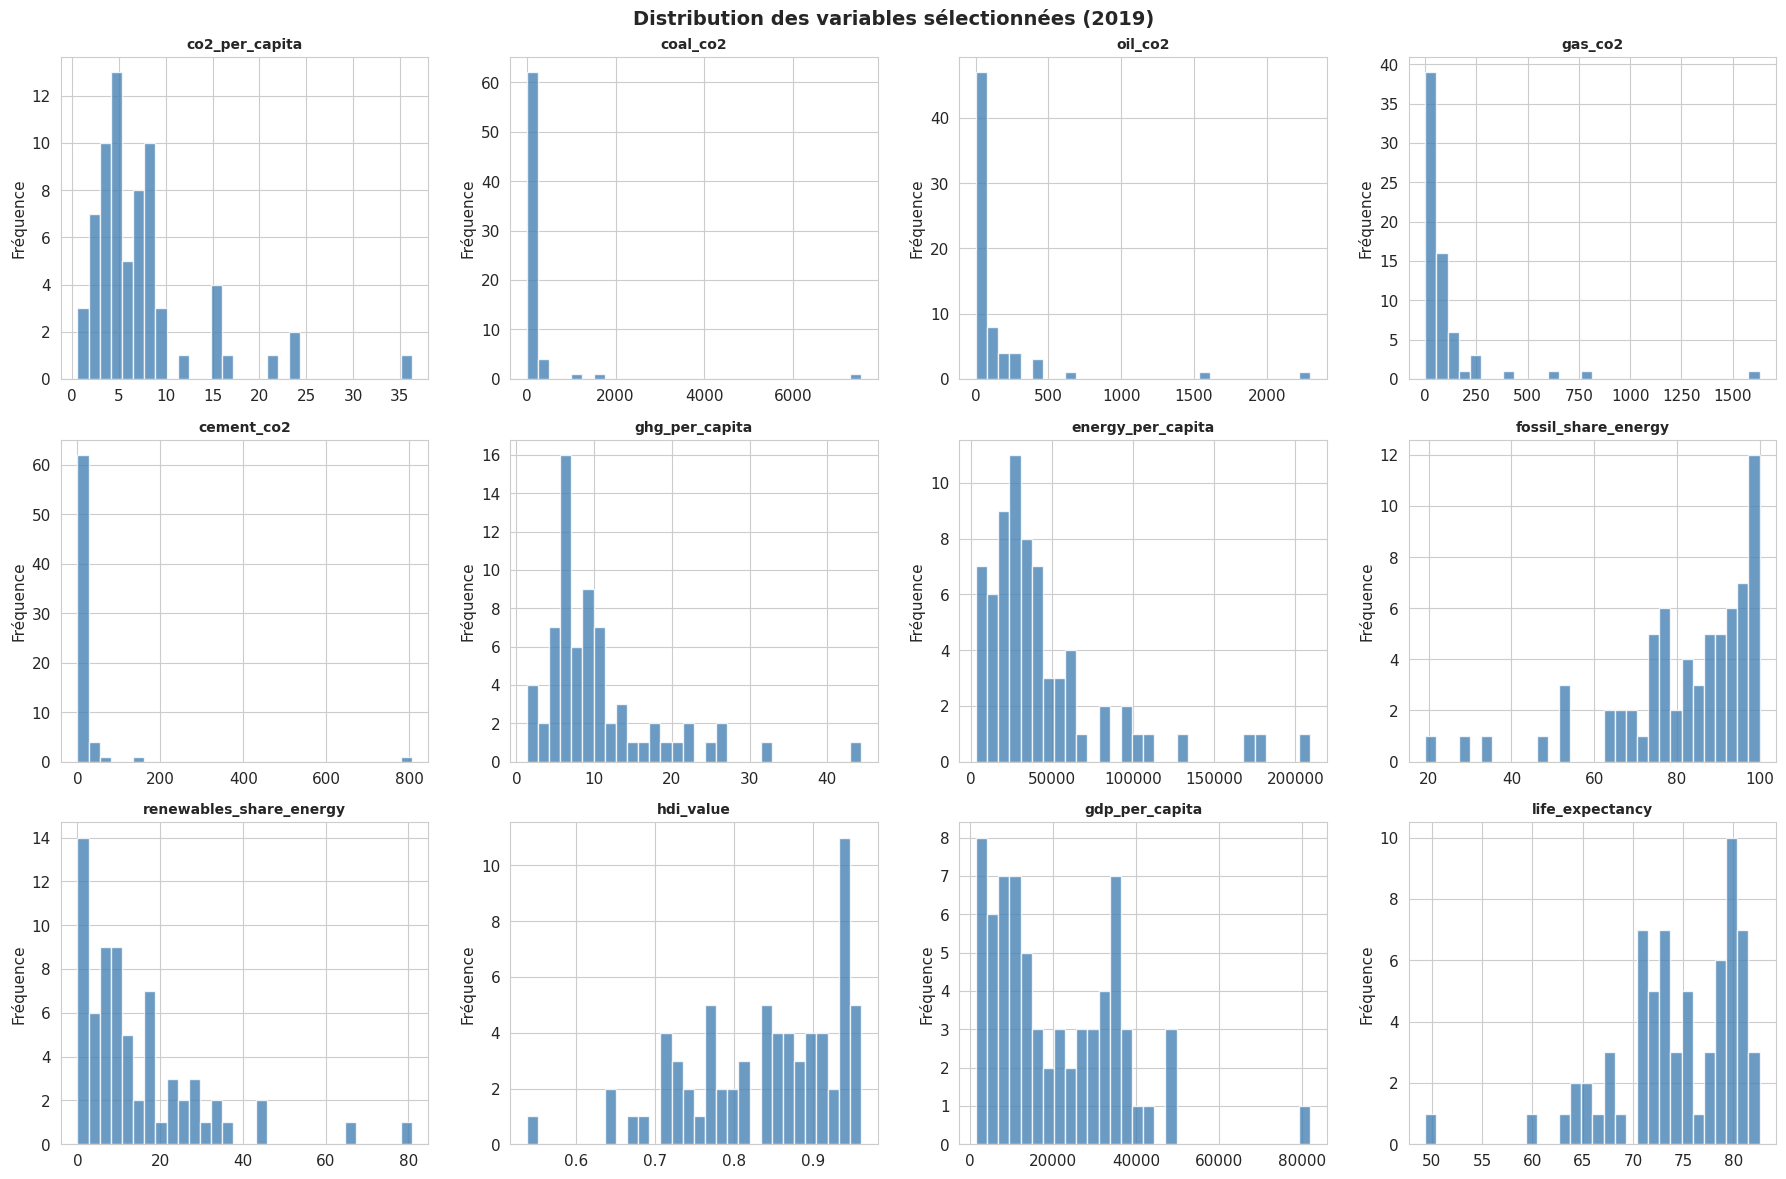

In [7]:
# ============================================================
# 2.1 DISTRIBUTIONS DES VARIABLES CLÉS
# ============================================================

fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    if i < len(axes):
        axes[i].hist(df_analysis[col].dropna(), bins=30, color='steelblue',
                     edgecolor='white', alpha=0.8)
        axes[i].set_title(col, fontsize=10, fontweight='bold')
        axes[i].set_ylabel('Fréquence')

# Masquer les axes inutilisés
for j in range(len(feature_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Distribution des variables sélectionnées (2019)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

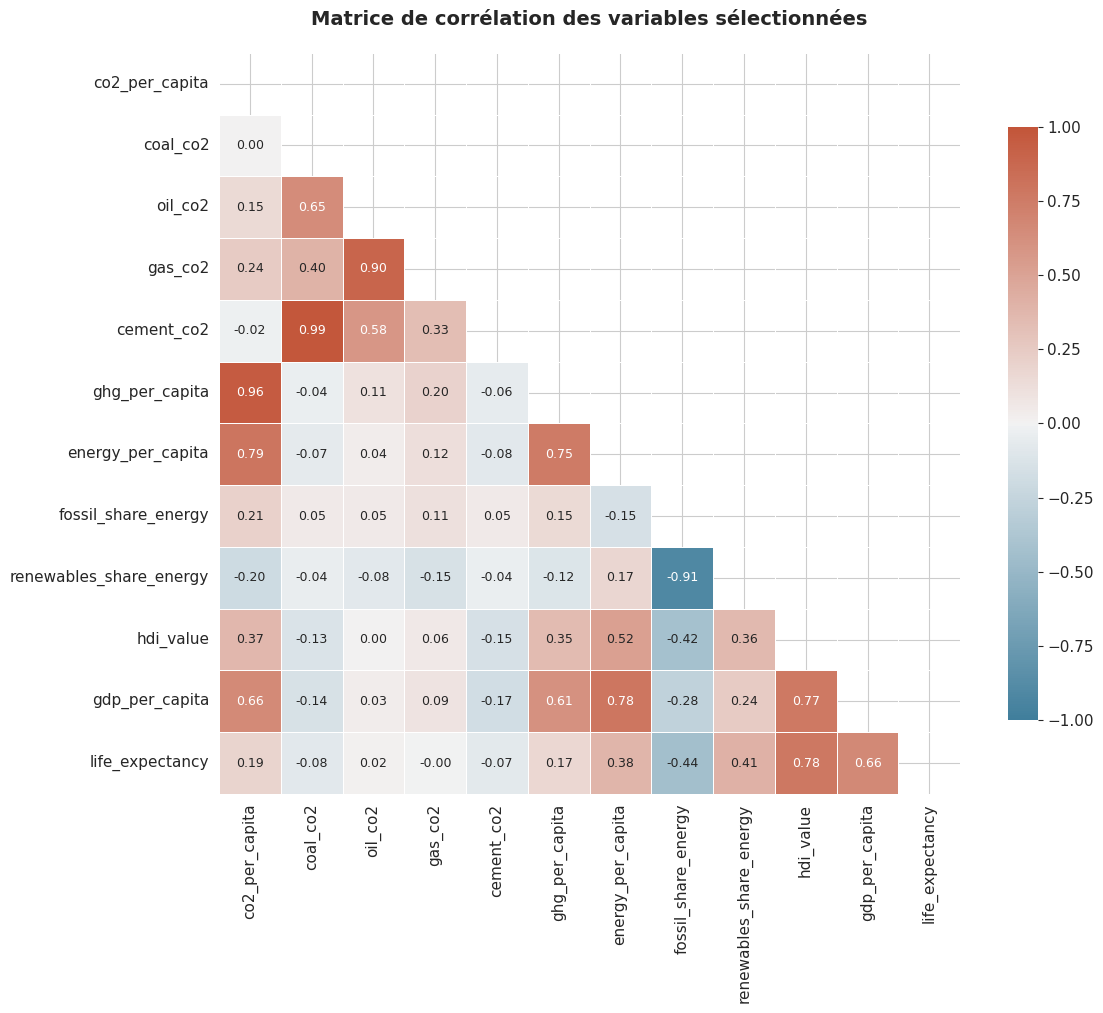


Observations clés :
- co2_per_capita et energy_per_capita sont fortement corrélés (développement = énergie = émissions)
- hdi_value corrélé positivement avec co2_per_capita et gdp_per_capita
- renewables_share_energy négativement corrélé avec fossil_share_energy (par construction)


In [8]:
# ============================================================
# 2.2 MATRICE DE CORRÉLATION
# ============================================================

corr_matrix = df_analysis[feature_cols].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
cmap = sns.diverging_palette(230, 20, as_cmap=True)

sns.heatmap(corr_matrix, mask=mask, cmap=cmap, vmax=1, vmin=-1,
            center=0, square=True, linewidths=0.5,
            annot=True, fmt='.2f', annot_kws={'size': 9},
            cbar_kws={"shrink": 0.8})

plt.title("Matrice de corrélation des variables sélectionnées",
          fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("\nObservations clés :")
print("- co2_per_capita et energy_per_capita sont fortement corrélés (développement = énergie = émissions)")
print("- hdi_value corrélé positivement avec co2_per_capita et gdp_per_capita")
print("- renewables_share_energy négativement corrélé avec fossil_share_energy (par construction)")

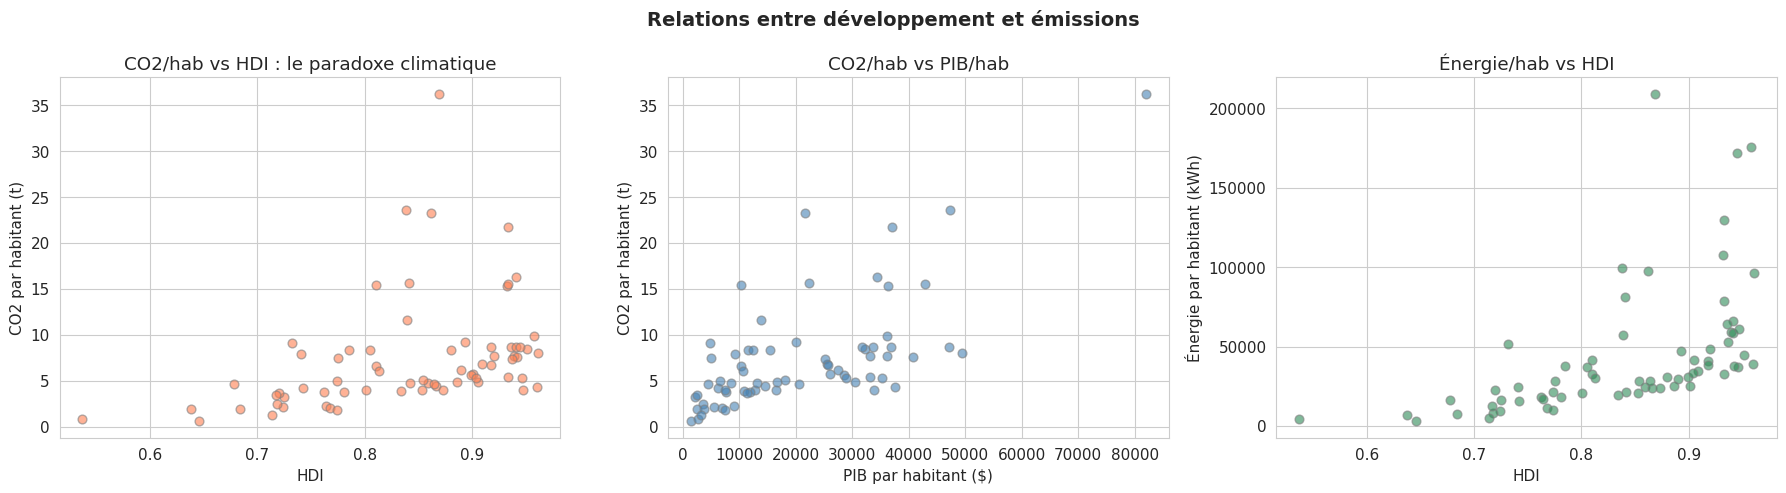

In [9]:
# ============================================================
# 2.3 SCATTER PLOTS : ÉMISSIONS vs DÉVELOPPEMENT
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# CO2/hab vs HDI
axes[0].scatter(df_analysis['hdi_value'], df_analysis['co2_per_capita'],
                alpha=0.6, c='coral', edgecolors='gray', s=40)
axes[0].set_xlabel('HDI')
axes[0].set_ylabel('CO2 par habitant (t)')
axes[0].set_title('CO2/hab vs HDI : le paradoxe climatique')

# CO2/hab vs GDP/hab
if 'gdp_per_capita' in df_analysis.columns:
    axes[1].scatter(df_analysis['gdp_per_capita'], df_analysis['co2_per_capita'],
                    alpha=0.6, c='steelblue', edgecolors='gray', s=40)
    axes[1].set_xlabel('PIB par habitant ($)')
    axes[1].set_ylabel('CO2 par habitant (t)')
    axes[1].set_title('CO2/hab vs PIB/hab')

# Energy/hab vs HDI
if 'energy_per_capita' in df_analysis.columns:
    axes[2].scatter(df_analysis['hdi_value'], df_analysis['energy_per_capita'],
                    alpha=0.6, c='seagreen', edgecolors='gray', s=40)
    axes[2].set_xlabel('HDI')
    axes[2].set_ylabel('Énergie par habitant (kWh)')
    axes[2].set_title('Énergie/hab vs HDI')

plt.suptitle("Relations entre développement et émissions", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 3. Réduction de dimension

Nous appliquons trois méthodes complémentaires :
- **ACP (PCA)** : identifier les axes principaux de variabilité — quel axe capture l'opposition "richesse vs vulnérabilité" ?
- **NMF** : sur les données de consommation énergétique (positives) pour extraire des profils de mix énergétique archétypaux
- **ICA** : sur le mix CO2 pour séparer des facteurs indépendants (politique industrielle, climat, richesse...)

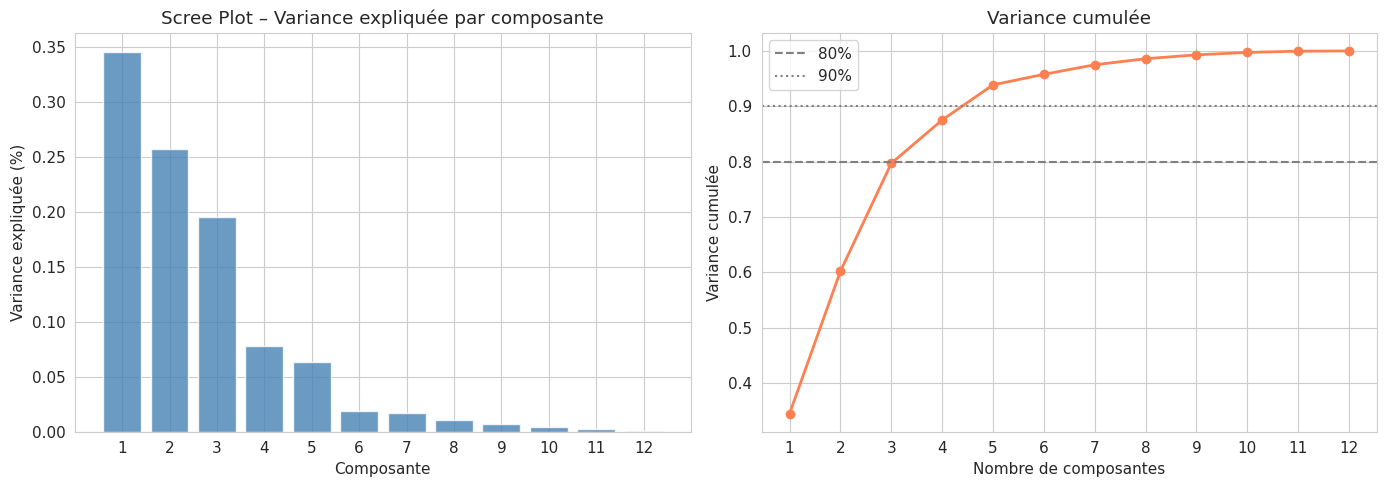


Composantes nécessaires pour 80% de variance : 4
Variance expliquée par les 2 premières composantes : 60.2%


In [10]:
# ============================================================
# 3.1 ACP (PCA) – ANALYSE EN COMPOSANTES PRINCIPALES
# ============================================================

# Standardisation des données (moyenne=0, écart-type=1)
X = df_analysis[feature_cols].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ACP avec toutes les composantes pour voir la variance expliquée
pca_full = PCA()
pca_full.fit(X_scaled)

# --- Variance expliquée ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scree plot
axes[0].bar(range(1, len(pca_full.explained_variance_ratio_) + 1),
            pca_full.explained_variance_ratio_, color='steelblue', alpha=0.8)
axes[0].set_xlabel('Composante')
axes[0].set_ylabel('Variance expliquée (%)')
axes[0].set_title('Scree Plot – Variance expliquée par composante')
axes[0].set_xticks(range(1, len(feature_cols) + 1))

# Variance cumulée
cum_var = np.cumsum(pca_full.explained_variance_ratio_)
axes[1].plot(range(1, len(cum_var) + 1), cum_var, 'o-', color='coral', linewidth=2)
axes[1].axhline(y=0.8, color='gray', linestyle='--', label='80%')
axes[1].axhline(y=0.9, color='gray', linestyle=':', label='90%')
axes[1].set_xlabel('Nombre de composantes')
axes[1].set_ylabel('Variance cumulée')
axes[1].set_title('Variance cumulée')
axes[1].legend()
axes[1].set_xticks(range(1, len(feature_cols) + 1))

plt.tight_layout()
plt.show()

# Nombre de composantes pour 80% de variance
n_comp_80 = np.argmax(cum_var >= 0.80) + 1
print(f"\nComposantes nécessaires pour 80% de variance : {n_comp_80}")
print(f"Variance expliquée par les 2 premières composantes : {cum_var[1]:.1%}")

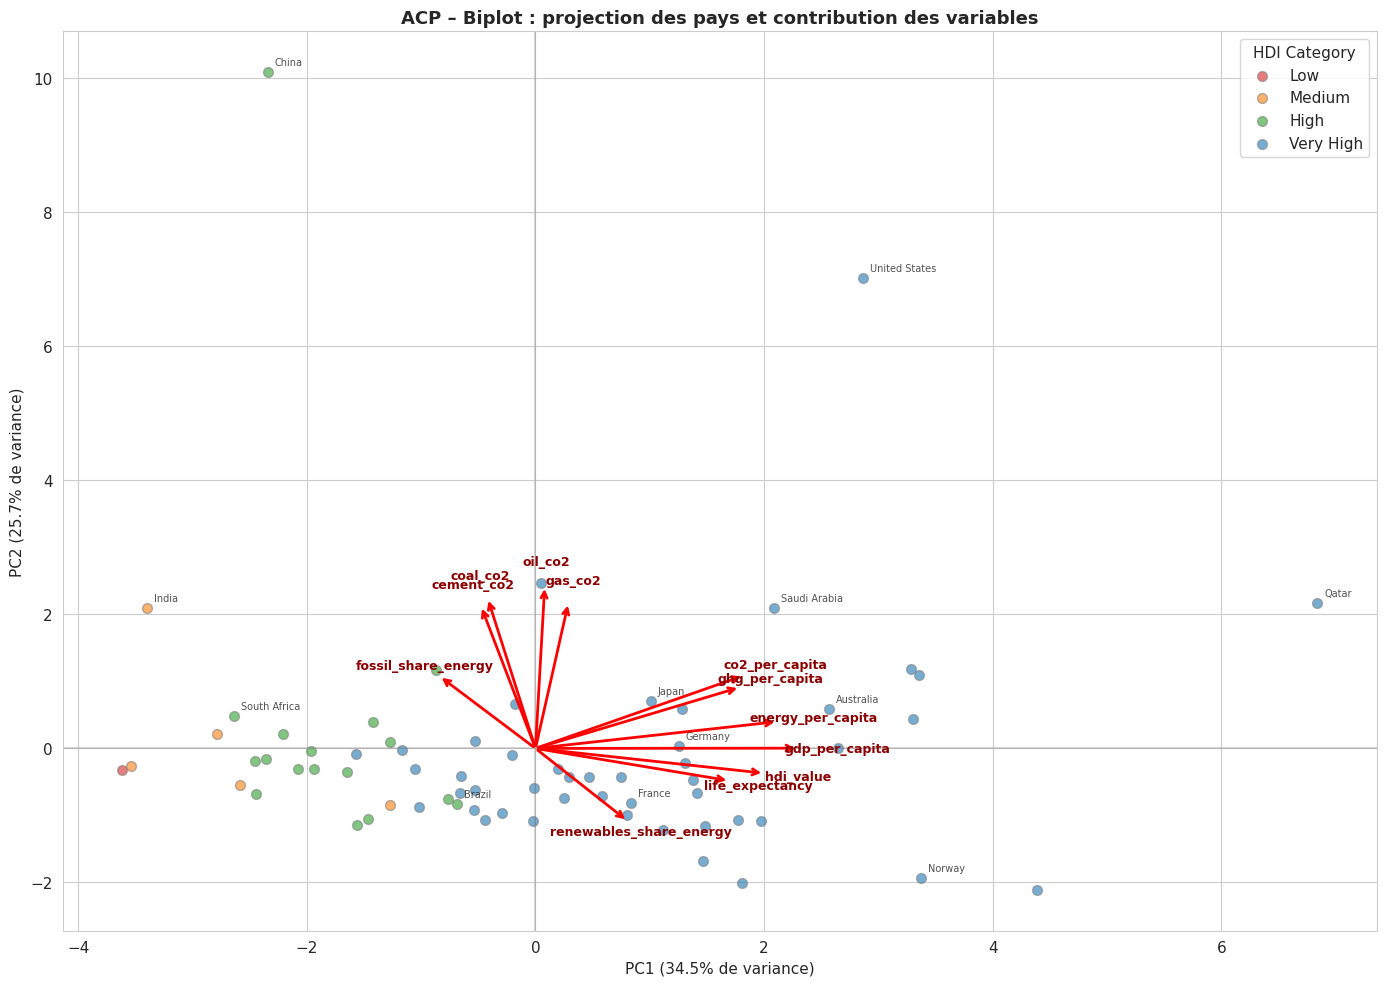


Loadings ACP (contribution des variables aux axes) :
                           PC1    PC2
co2_per_capita           0.364  0.217
coal_co2                -0.084  0.448
oil_co2                  0.016  0.484
gas_co2                  0.058  0.435
cement_co2              -0.095  0.425
ghg_per_capita           0.358  0.182
energy_per_capita        0.423  0.080
fossil_share_energy     -0.168  0.215
renewables_share_energy  0.161 -0.216
hdi_value                0.400 -0.074
gdp_per_capita           0.460  0.001
life_expectancy          0.339 -0.096

Interprétation :
- PC1 capture l'opposition 'richesse/développement vs pauvreté'
  (co2_per_capita, energy_per_capita, hdi, gdp corrélés positivement)
- PC2 capture le type de mix énergétique (fossile vs renouvelable)


In [11]:
# ============================================================
# 3.2 ACP – BIPLOT ET INTERPRÉTATION DES LOADINGS
# ============================================================

# ACP à 2 composantes pour la visualisation
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df_analysis['PC1'] = X_pca[:, 0]
df_analysis['PC2'] = X_pca[:, 1]

# --- Biplot ---
fig, ax = plt.subplots(figsize=(14, 10))

# Points des pays colorés par HDI
if 'hdicode' in df_analysis.columns:
    hdi_colors = {'Low': '#d62728', 'Medium': '#ff7f0e', 'High': '#2ca02c', 'Very High': '#1f77b4'}
    for code, color in hdi_colors.items():
        mask = df_analysis['hdicode'] == code
        ax.scatter(X_pca[mask, 0], X_pca[mask, 1], c=color, label=code,
                   alpha=0.6, s=50, edgecolors='gray')
else:
    ax.scatter(X_pca[:, 0], X_pca[:, 1], c='steelblue', alpha=0.6, s=50)

# Flèches des variables (loadings)
loadings = pca.components_.T
scale = 5  # Facteur d'échelle pour la lisibilité
for i, col in enumerate(feature_cols):
    ax.annotate('', xy=(loadings[i, 0] * scale, loadings[i, 1] * scale),
                xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color='red', lw=2))
    ax.text(loadings[i, 0] * scale * 1.15, loadings[i, 1] * scale * 1.15,
            col, fontsize=9, color='darkred', fontweight='bold',
            ha='center', va='center')

# Annoter quelques pays remarquables
for _, row in df_analysis.iterrows():
    if row['country'] in ['United States', 'China', 'India', 'France', 'Qatar',
                          'Norway', 'Nigeria', 'Brazil', 'Germany', 'Saudi Arabia',
                          'Japan', 'Ethiopia', 'South Africa', 'Australia']:
        ax.annotate(row['country'], (row['PC1'], row['PC2']),
                    fontsize=7, alpha=0.8,
                    textcoords="offset points", xytext=(5, 5))

ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} de variance)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} de variance)")
ax.set_title("ACP – Biplot : projection des pays et contribution des variables", fontsize=13, fontweight='bold')
ax.legend(title='HDI Category', loc='upper right')
ax.axhline(y=0, color='gray', linestyle='-', alpha=0.3)
ax.axvline(x=0, color='gray', linestyle='-', alpha=0.3)
plt.tight_layout()
plt.show()

# --- Tableau des loadings ---
loadings_df = pd.DataFrame(
    pca.components_.T,
    columns=['PC1', 'PC2'],
    index=feature_cols
)
print("\nLoadings ACP (contribution des variables aux axes) :")
print(loadings_df.round(3))
print("\nInterprétation :")
print("- PC1 capture l'opposition 'richesse/développement vs pauvreté'")
print("  (co2_per_capita, energy_per_capita, hdi, gdp corrélés positivement)")
print("- PC2 capture le type de mix énergétique (fossile vs renouvelable)")

### 3.2 NMF – Factorisation en Matrices Non-négatives

Les données de **consommation énergétique** (charbon, gaz, pétrole, nucléaire, renouvelables...) sont **strictement positives**. La NMF est particulièrement adaptée car elle extrait des **profils additifs positifs** : chaque pays est une combinaison positive de profils archétypaux de mix énergétique.

On trace l'erreur de reconstruction $\|X - WH\|_F$ en fonction de $k$ pour choisir le nombre de composantes.

Colonnes énergie pour NMF : ['coal_consumption', 'gas_consumption', 'oil_consumption', 'nuclear_consumption', 'renewables_consumption', 'hydro_consumption', 'solar_consumption', 'wind_consumption']


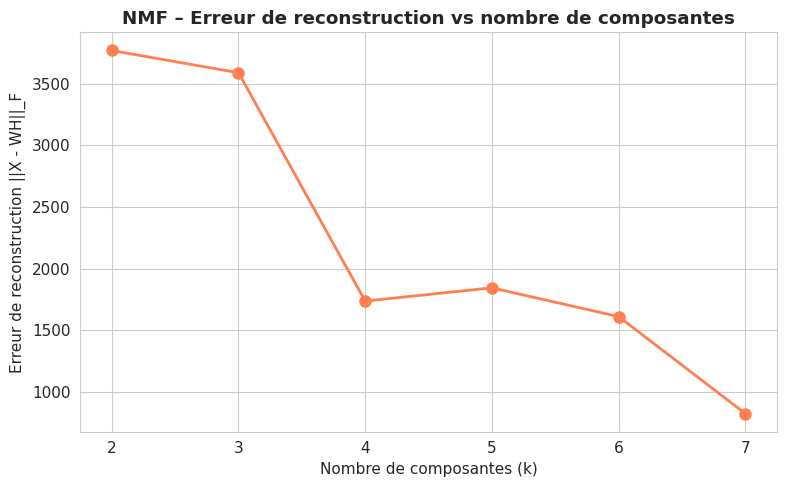


Nombre de composantes NMF retenu : 4


In [12]:
# ============================================================
# 3.3 NMF – PROFILS DE MIX ÉNERGÉTIQUE
# ============================================================

# Variables de consommation énergétique (positives)
energy_cols = [c for c in [
    'coal_consumption', 'gas_consumption', 'oil_consumption',
    'nuclear_consumption', 'renewables_consumption', 'hydro_consumption',
    'solar_consumption', 'wind_consumption'
] if c in df_analysis.columns]

print("Colonnes énergie pour NMF :", energy_cols)

# Préparer les données NMF : valeurs positives, remplacer NaN par 0
X_energy = df_analysis[energy_cols].fillna(0).values
X_energy = np.clip(X_energy, 0, None)  # S'assurer que tout est >= 0

# --- Choix du nombre de composantes : erreur de reconstruction ---
k_range = range(2, 8)
reconstruction_errors = []

for k in k_range:
    nmf = NMF(n_components=k, init='nndsvda', max_iter=500, random_state=42)
    W = nmf.fit_transform(X_energy)
    H = nmf.components_
    error = np.linalg.norm(X_energy - W @ H, 'fro')
    reconstruction_errors.append(error)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(list(k_range), reconstruction_errors, 'o-', color='coral', linewidth=2, markersize=8)
ax.set_xlabel('Nombre de composantes (k)')
ax.set_ylabel('Erreur de reconstruction ||X - WH||_F')
ax.set_title('NMF – Erreur de reconstruction vs nombre de composantes', fontweight='bold')
ax.set_xticks(list(k_range))
plt.tight_layout()
plt.show()

# On choisit k=4 (coude visible)
N_COMP_NMF = 4
print(f"\nNombre de composantes NMF retenu : {N_COMP_NMF}")

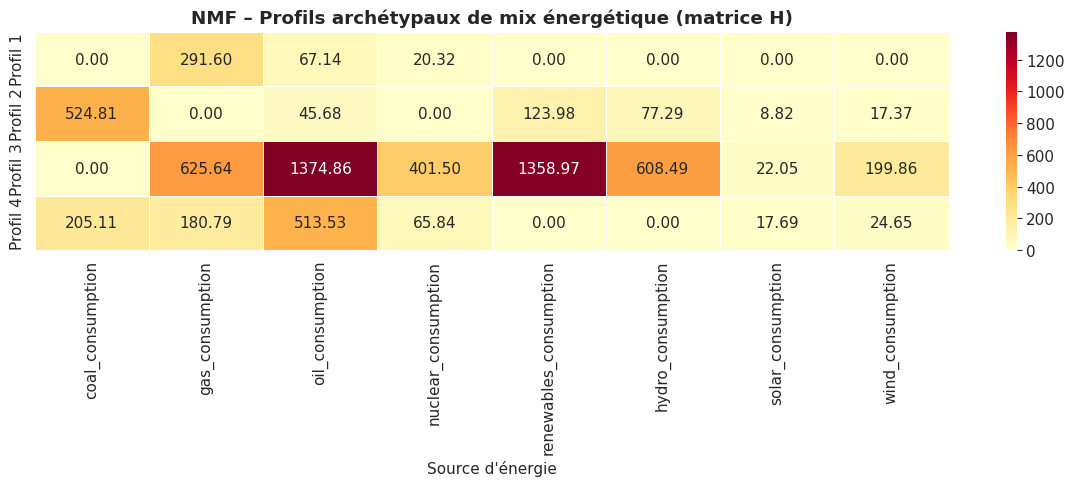

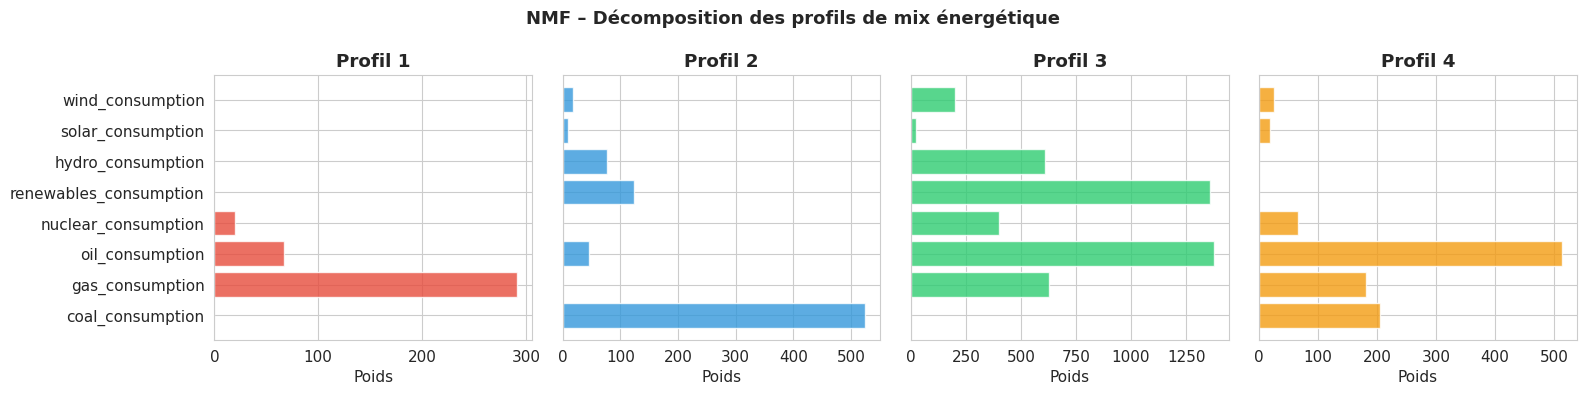

Interprétation des profils NMF :
Chaque profil représente un archétype de mix énergétique.
Les pays sont des combinaisons positives de ces profils.
Contrairement à l'ACP, les composantes NMF sont directement interprétables
car tous les coefficients sont positifs (profils additifs).


In [13]:
# ============================================================
# 3.4 NMF – VISUALISATION DES PROFILS ARCHÉTYPAUX
# ============================================================

nmf_final = NMF(n_components=N_COMP_NMF, init='nndsvda', max_iter=500, random_state=42)
W_nmf = nmf_final.fit_transform(X_energy)
H_nmf = nmf_final.components_

# Heatmap des composantes NMF (H) : chaque ligne = un profil archétypal
fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(H_nmf, annot=True, fmt='.2f', cmap='YlOrRd',
            xticklabels=energy_cols,
            yticklabels=[f'Profil {i+1}' for i in range(N_COMP_NMF)],
            ax=ax, linewidths=0.5)
ax.set_title('NMF – Profils archétypaux de mix énergétique (matrice H)', fontweight='bold')
ax.set_xlabel('Source d\'énergie')
plt.tight_layout()
plt.show()

# Barplot des profils
fig, axes = plt.subplots(1, N_COMP_NMF, figsize=(16, 4), sharey=True)
colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']
for i in range(N_COMP_NMF):
    axes[i].barh(energy_cols, H_nmf[i], color=colors[i], alpha=0.8)
    axes[i].set_title(f'Profil {i+1}', fontweight='bold')
    axes[i].set_xlabel('Poids')

plt.suptitle('NMF – Décomposition des profils de mix énergétique', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("Interprétation des profils NMF :")
print("Chaque profil représente un archétype de mix énergétique.")
print("Les pays sont des combinaisons positives de ces profils.")
print("Contrairement à l'ACP, les composantes NMF sont directement interprétables")
print("car tous les coefficients sont positifs (profils additifs).")

In [14]:
# ============================================================
# 3.5 NMF – TOP PAYS PAR PROFIL
# ============================================================

# Ajouter les poids NMF au DataFrame
for i in range(N_COMP_NMF):
    df_analysis[f'NMF_{i+1}'] = W_nmf[:, i]

# Top 5 pays par profil NMF
print("=" * 60)
for i in range(N_COMP_NMF):
    col_name = f'NMF_{i+1}'
    top5 = df_analysis.nlargest(5, col_name)[['country', col_name]]
    print(f"\nTop 5 pays – Profil {i+1} :")
    for _, row in top5.iterrows():
        print(f"  {row['country']:25s} : {row[col_name]:.1f}")


Top 5 pays – Profil 1 :
  United States             : 17.0
  Russia                    : 14.0
  Iran                      : 6.9
  China                     : 3.3
  Mexico                    : 2.3

Top 5 pays – Profil 2 :
  China                     : 39.3
  India                     : 7.5
  South Africa              : 1.7
  Russia                    : 1.5
  Japan                     : 1.3

Top 5 pays – Profil 3 :
  United States             : 1.7
  Brazil                    : 1.0
  Canada                    : 0.8
  Germany                   : 0.4
  France                    : 0.4

Top 5 pays – Profil 4 :
  United States             : 13.4
  China                     : 11.2
  India                     : 4.6
  Japan                     : 3.3
  Saudi Arabia              : 2.5


### 3.3 ICA – Analyse en Composantes Indépendantes

Le mix CO2 d'un pays (charbon, pétrole, gaz, ciment, land-use) peut être vu comme un **mélange de facteurs indépendants** (politique industrielle, climat, richesse...). L'ICA cherche à séparer ces facteurs en maximisant l'**indépendance statistique** (et non la variance comme l'ACP).

On vérifie l'hypothèse de **non-gaussianité** via le kurtosis.

In [15]:
# ============================================================
# 3.6 ICA – SÉPARATION DE FACTEURS INDÉPENDANTS
# ============================================================

# Variables du mix CO2 par source
co2_mix_cols = [c for c in ['coal_co2', 'oil_co2', 'gas_co2', 'cement_co2']
                if c in df_analysis.columns]
print("Colonnes CO2 mix pour ICA :", co2_mix_cols)

X_co2_mix = df_analysis[co2_mix_cols].fillna(0).values

# Standardiser avant ICA
scaler_ica = StandardScaler()
X_co2_scaled = scaler_ica.fit_transform(X_co2_mix)

# Appliquer FastICA
n_ica = len(co2_mix_cols)
ica = FastICA(n_components=n_ica, random_state=42, max_iter=1000)
X_ica = ica.fit_transform(X_co2_scaled)

# Matrice de mélange (mixing matrix)
mixing_matrix = ica.mixing_

# --- Vérification de la non-gaussianité : kurtosis ---
print("\n" + "=" * 60)
print("VÉRIFICATION DE NON-GAUSSIANITÉ (kurtosis)")
print("=" * 60)
print("\nKurtosis des variables originales (excess kurtosis, gaussien = 0) :")
for i, col in enumerate(co2_mix_cols):
    k = kurtosis(X_co2_scaled[:, i], fisher=True)
    print(f"  {col:20s} : {k:.2f}")

print("\nKurtosis des composantes ICA :")
for i in range(n_ica):
    k = kurtosis(X_ica[:, i], fisher=True)
    print(f"  IC{i+1:18d} : {k:.2f}")

print("\nNote : Un kurtosis élevé (>> 0) confirme la non-gaussianité,")
print("condition nécessaire pour que l'ICA fonctionne correctement.")

Colonnes CO2 mix pour ICA : ['coal_co2', 'oil_co2', 'gas_co2', 'cement_co2']

VÉRIFICATION DE NON-GAUSSIANITÉ (kurtosis)

Kurtosis des variables originales (excess kurtosis, gaussien = 0) :
  coal_co2             : 55.01
  oil_co2              : 25.51
  gas_co2              : 28.07
  cement_co2           : 58.67

Kurtosis des composantes ICA :
  IC                 1 : 4.08
  IC                 2 : 22.34
  IC                 3 : 59.68
  IC                 4 : 47.79

Note : Un kurtosis élevé (>> 0) confirme la non-gaussianité,
condition nécessaire pour que l'ICA fonctionne correctement.


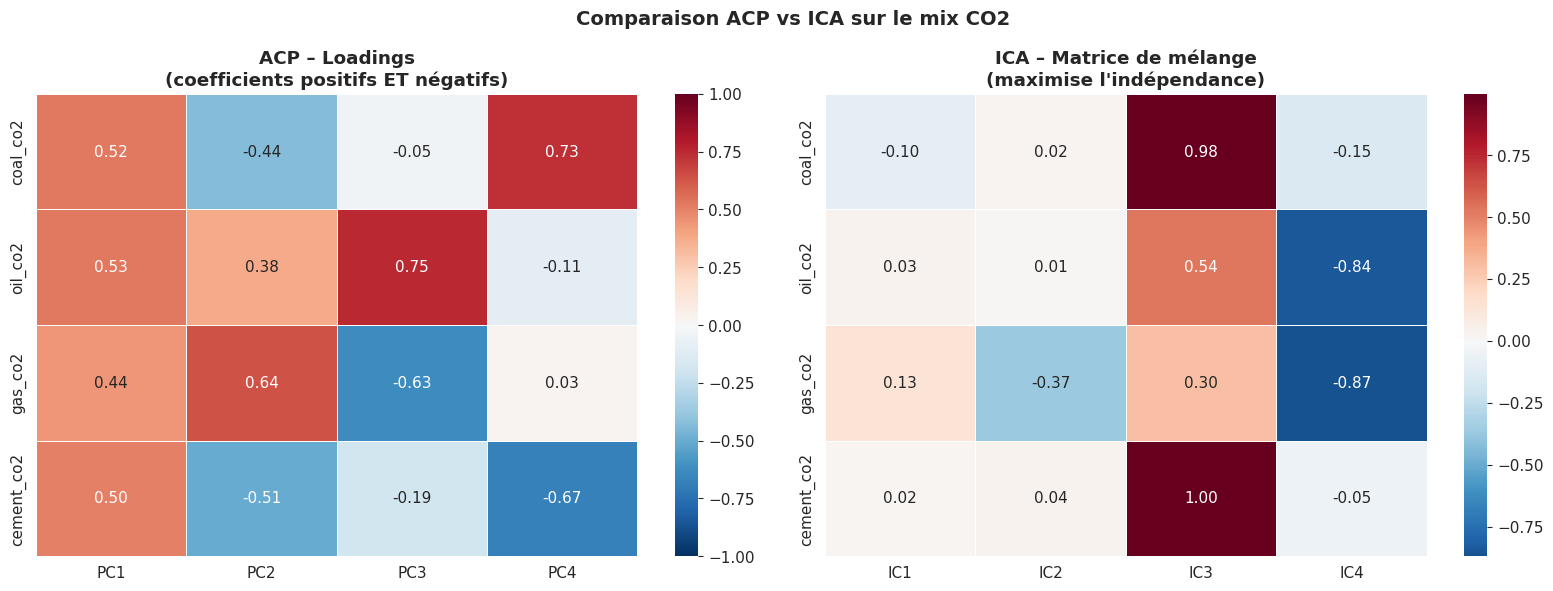


Comparaison ACP vs ICA :
--------------------------------------------------
ACP : maximise la variance. Les axes sont orthogonaux et ordonnés
      par variance décroissante. Coefficients positifs et négatifs.
ICA : maximise l'indépendance statistique. Les composantes
      représentent des sources indépendantes (facteurs latents).
      Plus interprétables quand les données sont un vrai mélange.

Dans notre cas, les composantes ICA capturent mieux les facteurs
structurels (ex: dépendance au charbon vs au gaz) car chaque
composante isole un facteur indépendant du mix énergétique.


In [16]:
# ============================================================
# 3.7 COMPARAISON ACP vs ICA
# ============================================================

# ACP sur les mêmes données CO2 mix
pca_co2 = PCA(n_components=n_ica)
X_pca_co2 = pca_co2.fit_transform(X_co2_scaled)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Heatmap ACP loadings
pca_loadings = pd.DataFrame(
    pca_co2.components_.T,
    index=co2_mix_cols,
    columns=[f'PC{i+1}' for i in range(n_ica)]
)
sns.heatmap(pca_loadings, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            ax=axes[0], linewidths=0.5, vmin=-1, vmax=1)
axes[0].set_title('ACP – Loadings\n(coefficients positifs ET négatifs)', fontweight='bold')

# Heatmap ICA mixing matrix
ica_loadings = pd.DataFrame(
    mixing_matrix,
    index=co2_mix_cols,
    columns=[f'IC{i+1}' for i in range(n_ica)]
)
sns.heatmap(ica_loadings, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            ax=axes[1], linewidths=0.5)
axes[1].set_title('ICA – Matrice de mélange\n(maximise l\'indépendance)', fontweight='bold')

plt.suptitle('Comparaison ACP vs ICA sur le mix CO2', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nComparaison ACP vs ICA :")
print("-" * 50)
print("ACP : maximise la variance. Les axes sont orthogonaux et ordonnés")
print("      par variance décroissante. Coefficients positifs et négatifs.")
print("ICA : maximise l'indépendance statistique. Les composantes")
print("      représentent des sources indépendantes (facteurs latents).")
print("      Plus interprétables quand les données sont un vrai mélange.")
print("\nDans notre cas, les composantes ICA capturent mieux les facteurs")
print("structurels (ex: dépendance au charbon vs au gaz) car chaque")
print("composante isole un facteur indépendant du mix énergétique.")

---
## 4. Clustering

### Démarche en deux étapes :
1. **Étape 1 – Pseudo-labels** : utiliser `hdicode` (Low/Medium/High/Very High) comme vérité terrain pour évaluer le clustering a posteriori (ARI, alignement hongrois), **sans l'utiliser dans l'estimation**.
2. **Étape 2 – Non supervisé pur** : K-Means (coude + silhouette), GMM (BIC/AIC), DBSCAN (k-distance plot). Comparer les trois partitionnements (ARI croisé).

Pays avec label HDI : 69
Distribution des classes HDI :
  Low        : 1 pays
  Medium     : 5 pays
  High       : 17 pays
  Very High  : 46 pays

K-Means (K=4) vs HDI :  ARI = 0.083


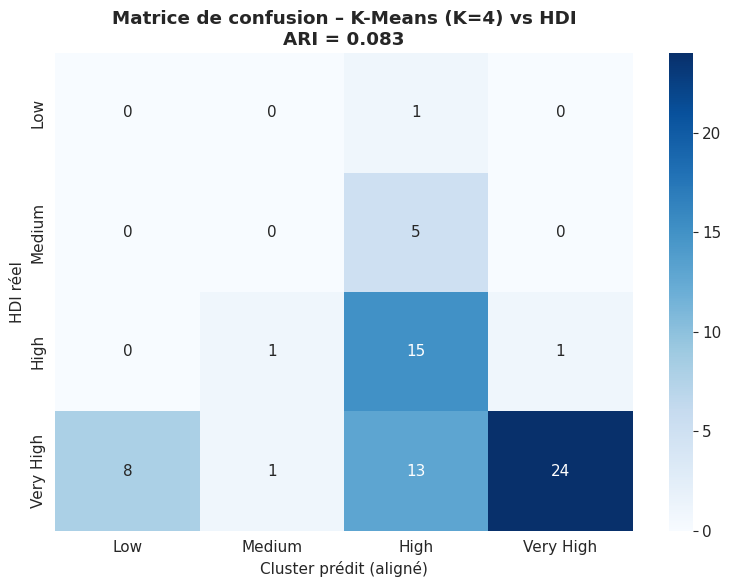

In [17]:
# ============================================================
# 4.1 ÉTAPE 1 – CLUSTERING AVEC PSEUDO-LABELS (HDI)
# ============================================================
# hdicode sert UNIQUEMENT à évaluer, PAS à construire les clusters

# Encoder les pseudo-labels HDI en numérique
hdi_mapping = {'Low': 0, 'Medium': 1, 'High': 2, 'Very High': 3}
df_analysis['hdi_label'] = df_analysis['hdicode'].map(hdi_mapping)

# Filtrer les pays avec un label HDI valide
mask_hdi = df_analysis['hdi_label'].notna()
X_clust = X_scaled[mask_hdi.values]
y_true = df_analysis.loc[mask_hdi, 'hdi_label'].astype(int).values
countries_clust = df_analysis.loc[mask_hdi, 'country'].values

print(f"Pays avec label HDI : {len(y_true)}")
print(f"Distribution des classes HDI :")
for name, c in hdi_mapping.items():
    print(f"  {name:10s} : {(y_true == c).sum()} pays")

# --- K-Means avec K=4 (nombre de catégories HDI) ---
kmeans_4 = KMeans(n_clusters=4, random_state=42, n_init=20)
labels_km4 = kmeans_4.fit_predict(X_clust)

# --- Alignement hongrois ---
def hungarian_align(y_true, y_pred):
    n_classes = max(y_true.max(), y_pred.max()) + 1
    cm = confusion_matrix(y_true, y_pred, labels=range(n_classes))
    row_ind, col_ind = linear_sum_assignment(-cm)
    mapping = {col: row for row, col in zip(row_ind, col_ind)}
    aligned = np.array([mapping.get(l, -1) for l in y_pred])
    return aligned, cm

labels_km4_aligned, _ = hungarian_align(y_true, labels_km4)

# --- ARI et matrice de confusion ---
ari_km4 = adjusted_rand_score(y_true, labels_km4)
print(f"\nK-Means (K=4) vs HDI :  ARI = {ari_km4:.3f}")

cm_aligned = confusion_matrix(y_true, labels_km4_aligned)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm_aligned, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Low','Medium','High','Very High'],
            yticklabels=['Low','Medium','High','Very High'], ax=ax)
ax.set_xlabel('Cluster prédit (aligné)')
ax.set_ylabel('HDI réel')
ax.set_title(f'Matrice de confusion – K-Means (K=4) vs HDI\nARI = {ari_km4:.3f}', fontweight='bold')
plt.tight_layout()
plt.show()

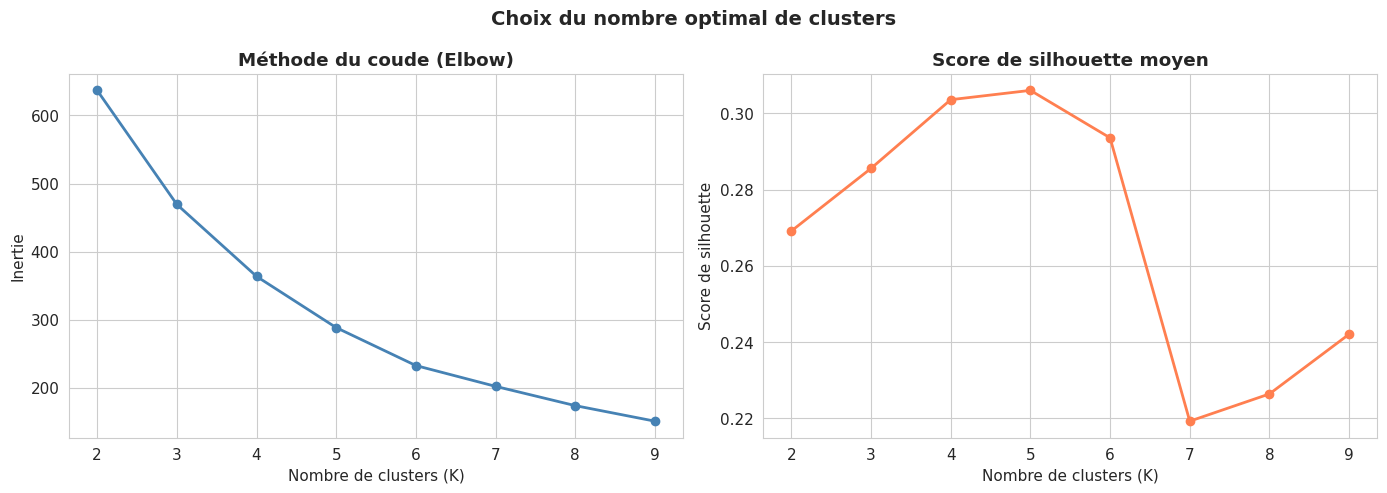

K optimal (silhouette) : 5
Silhouette scores : {2: np.float64(0.269), 3: np.float64(0.286), 4: np.float64(0.304), 5: np.float64(0.306), 6: np.float64(0.294), 7: np.float64(0.219), 8: np.float64(0.226), 9: np.float64(0.242)}


In [18]:
# ============================================================
# 4.2 ÉTAPE 2 – NON SUPERVISÉ : CHOIX DE K (Elbow + Silhouette)
# ============================================================

K_range = range(2, 10)
inertias = []
silhouettes = []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=15)
    labels = km.fit_predict(X_clust)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_clust, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(K_range), inertias, 'o-', color='steelblue', linewidth=2)
axes[0].set_xlabel('Nombre de clusters (K)')
axes[0].set_ylabel('Inertie')
axes[0].set_title('Méthode du coude (Elbow)', fontweight='bold')
axes[0].set_xticks(list(K_range))

axes[1].plot(list(K_range), silhouettes, 'o-', color='coral', linewidth=2)
axes[1].set_xlabel('Nombre de clusters (K)')
axes[1].set_ylabel('Score de silhouette')
axes[1].set_title('Score de silhouette moyen', fontweight='bold')
axes[1].set_xticks(list(K_range))

plt.suptitle('Choix du nombre optimal de clusters', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

k_best_sil = list(K_range)[np.argmax(silhouettes)]
print(f"K optimal (silhouette) : {k_best_sil}")
print(f"Silhouette scores : { {k: round(s,3) for k,s in zip(K_range, silhouettes)} }")

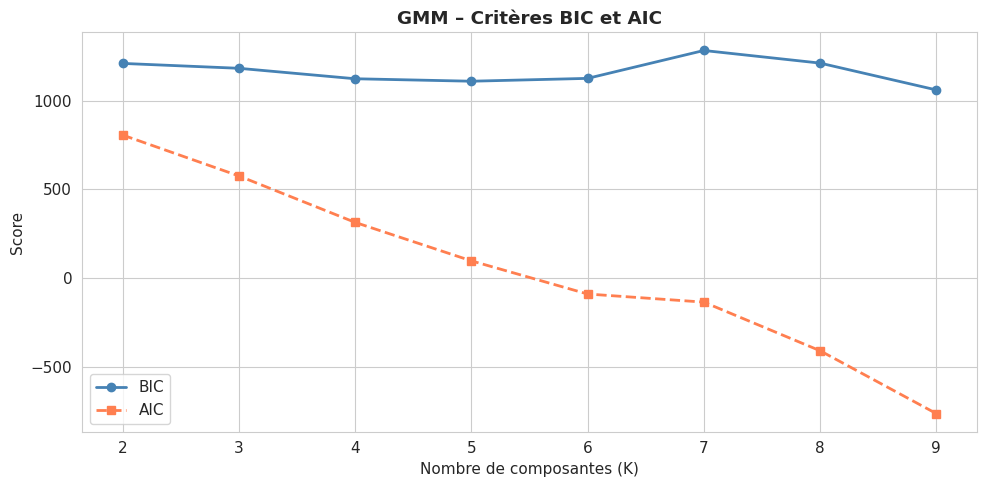

K optimal (BIC) : 9
K optimal (AIC) : 9
Silhouette GMM (K=9) : 0.220


In [19]:
# ============================================================
# 4.3 GMM – GAUSSIAN MIXTURE MODEL (BIC / AIC)
# ============================================================

K_range_gmm = range(2, 10)
bics = []
aics = []

for k in K_range_gmm:
    gmm = GaussianMixture(n_components=k, random_state=42, n_init=5)
    gmm.fit(X_clust)
    bics.append(gmm.bic(X_clust))
    aics.append(gmm.aic(X_clust))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(list(K_range_gmm), bics, 'o-', color='steelblue', linewidth=2, label='BIC')
ax.plot(list(K_range_gmm), aics, 's--', color='coral', linewidth=2, label='AIC')
ax.set_xlabel('Nombre de composantes (K)')
ax.set_ylabel('Score')
ax.set_title('GMM – Critères BIC et AIC', fontweight='bold')
ax.set_xticks(list(K_range_gmm))
ax.legend()
plt.tight_layout()
plt.show()

k_best_bic = list(K_range_gmm)[np.argmin(bics)]
k_best_aic = list(K_range_gmm)[np.argmin(aics)]
print(f"K optimal (BIC) : {k_best_bic}")
print(f"K optimal (AIC) : {k_best_aic}")

# GMM final
gmm_final = GaussianMixture(n_components=k_best_bic, random_state=42, n_init=5)
labels_gmm = gmm_final.fit_predict(X_clust)
sil_gmm = silhouette_score(X_clust, labels_gmm)
print(f"Silhouette GMM (K={k_best_bic}) : {sil_gmm:.3f}")

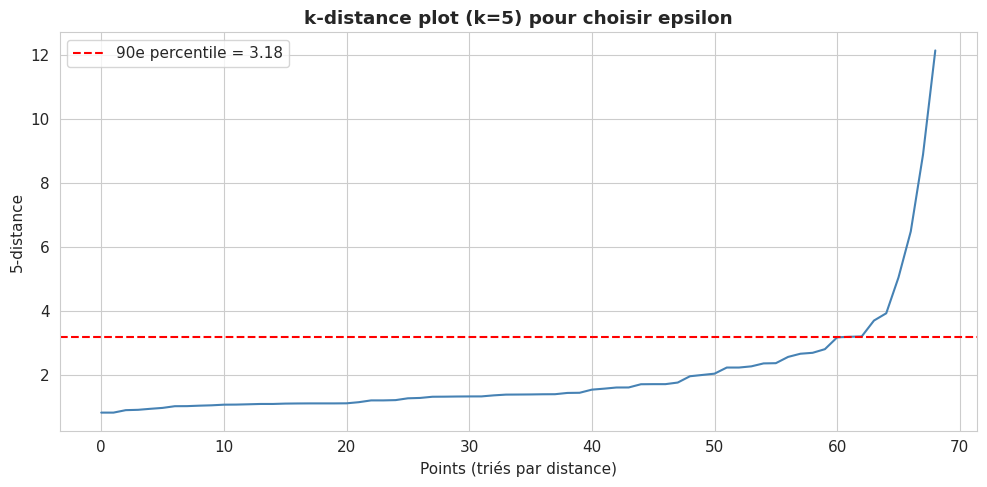

DBSCAN (eps=3.18, min_samples=5) :
  Clusters trouvés : 1
  Points bruit (outliers) : 4 (5.8%)


In [20]:
# ============================================================
# 4.4 DBSCAN – k-distance plot + clustering
# ============================================================

k_neighbors = 5
nn = NearestNeighbors(n_neighbors=k_neighbors)
nn.fit(X_clust)
distances, _ = nn.kneighbors(X_clust)
k_distances = np.sort(distances[:, -1])

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(k_distances, color='steelblue', linewidth=1.5)
ax.set_xlabel('Points (triés par distance)')
ax.set_ylabel(f'{k_neighbors}-distance')
ax.set_title(f'k-distance plot (k={k_neighbors}) pour choisir epsilon', fontweight='bold')
eps_val = np.percentile(k_distances, 90)
ax.axhline(y=eps_val, color='red', linestyle='--',
           label=f'90e percentile = {eps_val:.2f}')
ax.legend()
plt.tight_layout()
plt.show()

dbscan = DBSCAN(eps=eps_val, min_samples=k_neighbors)
labels_dbscan = dbscan.fit_predict(X_clust)

n_clusters_db = len(set(labels_dbscan)) - (1 if -1 in labels_dbscan else 0)
n_noise = (labels_dbscan == -1).sum()
print(f"DBSCAN (eps={eps_val:.2f}, min_samples={k_neighbors}) :")
print(f"  Clusters trouvés : {n_clusters_db}")
print(f"  Points bruit (outliers) : {n_noise} ({n_noise/len(labels_dbscan):.1%})")

if n_clusters_db > 1:
    mask_nn = labels_dbscan != -1
    sil_db = silhouette_score(X_clust[mask_nn], labels_dbscan[mask_nn])
    print(f"  Silhouette (hors bruit) : {sil_db:.3f}")

ARI avec les pseudo-labels HDI :
---------------------------------------------
  K-Means (K=5)             : ARI = 0.084
  GMM (K=9)                 : ARI = 0.079
  DBSCAN                    : ARI = -0.024


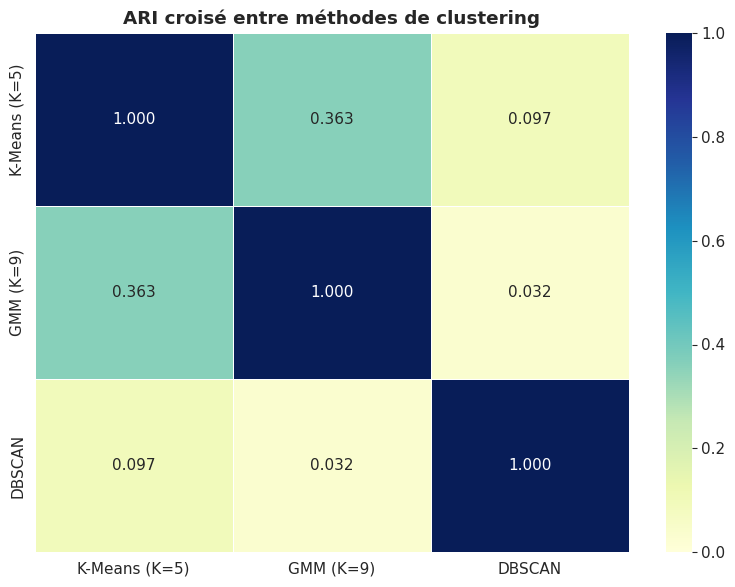

In [21]:
# ============================================================
# 4.5 COMPARAISON DES PARTITIONNEMENTS (ARI CROISÉ)
# ============================================================

# K-Means avec K optimal (silhouette)
kmeans_opt = KMeans(n_clusters=k_best_sil, random_state=42, n_init=20)
labels_km_opt = kmeans_opt.fit_predict(X_clust)

methods = {
    f'K-Means (K={k_best_sil})': labels_km_opt,
    f'GMM (K={k_best_bic})': labels_gmm,
    'DBSCAN': labels_dbscan,
}

# ARI avec les pseudo-labels HDI
print("ARI avec les pseudo-labels HDI :")
print("-" * 45)
for name, labels in methods.items():
    ari = adjusted_rand_score(y_true, labels)
    print(f"  {name:25s} : ARI = {ari:.3f}")

# ARI croisé entre méthodes
method_names = list(methods.keys())
ari_matrix = np.zeros((len(methods), len(methods)))
for i, (n1, l1) in enumerate(methods.items()):
    for j, (n2, l2) in enumerate(methods.items()):
        ari_matrix[i, j] = adjusted_rand_score(l1, l2)

ari_df = pd.DataFrame(ari_matrix, index=method_names, columns=method_names)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(ari_df, annot=True, fmt='.3f', cmap='YlGnBu',
            ax=ax, linewidths=0.5, vmin=0, vmax=1)
ax.set_title('ARI croisé entre méthodes de clustering', fontweight='bold')
plt.tight_layout()
plt.show()

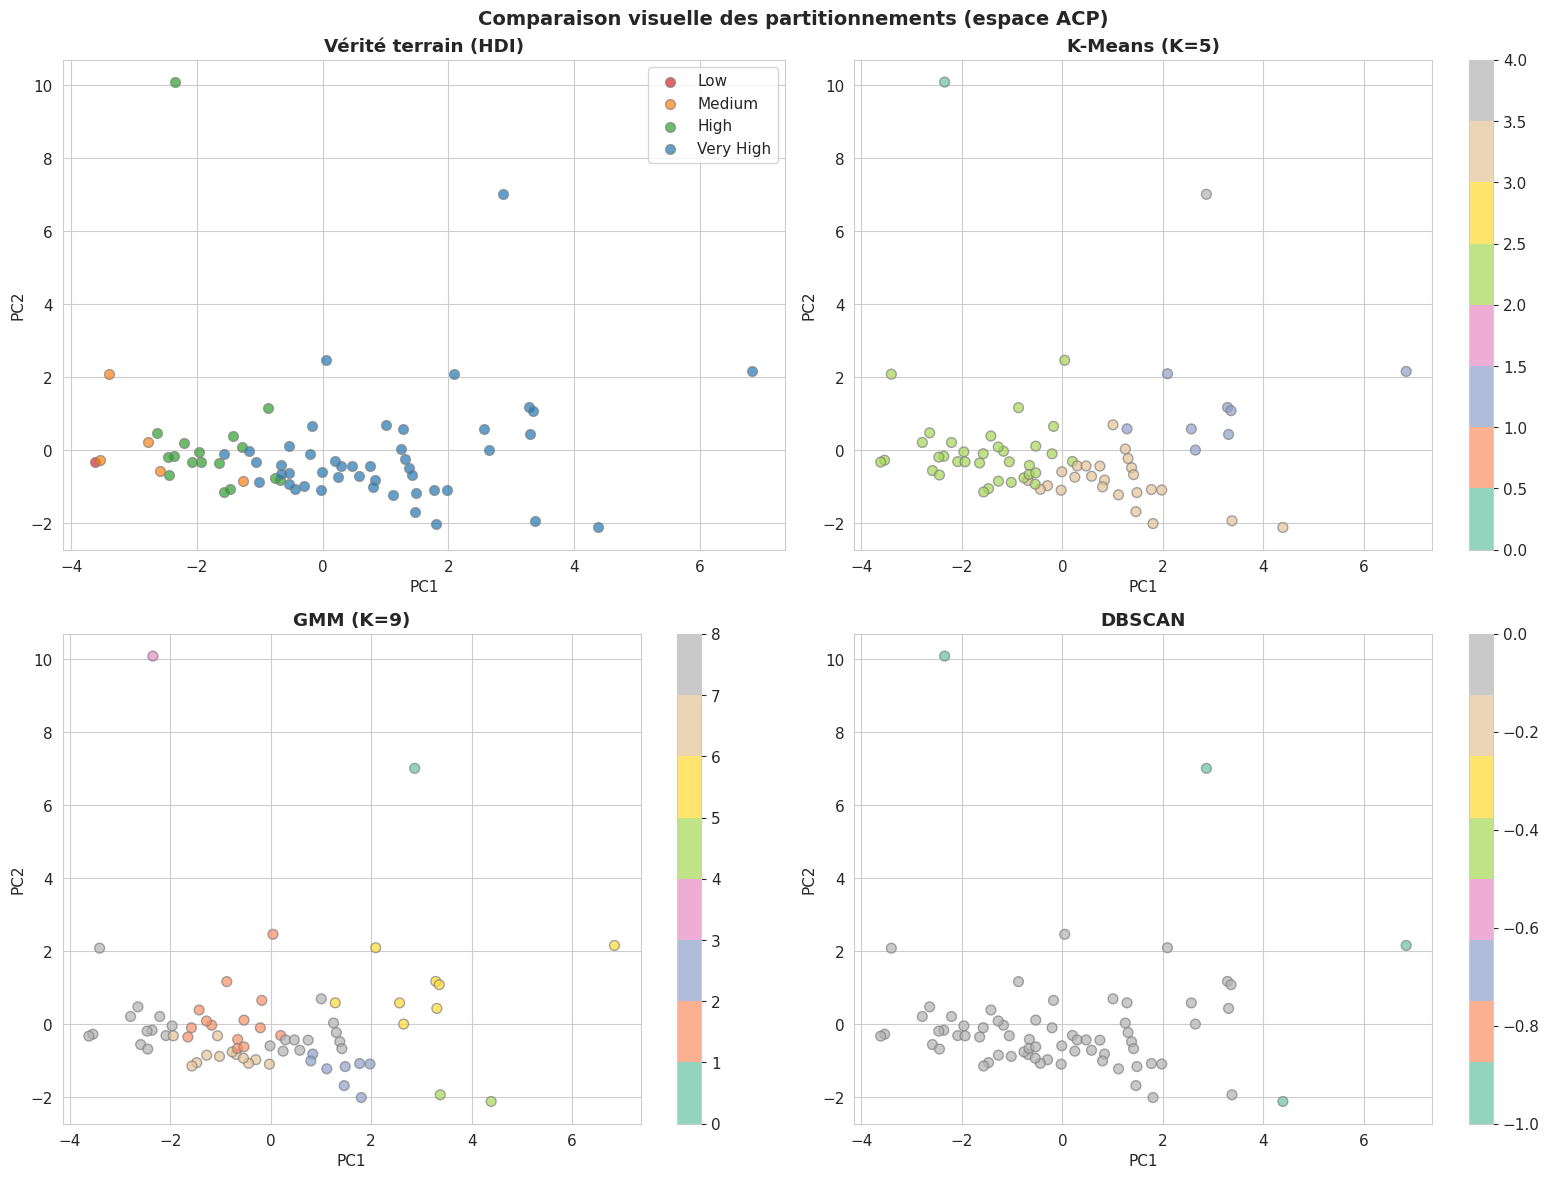

In [22]:
# ============================================================
# 4.6 VISUALISATION DES CLUSTERS (projection ACP 2D)
# ============================================================

X_pca_clust = PCA(n_components=2).fit_transform(X_clust)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# HDI réel
colors_hdi = {0:'#d62728', 1:'#ff7f0e', 2:'#2ca02c', 3:'#1f77b4'}
for label, color in colors_hdi.items():
    m = y_true == label
    axes[0,0].scatter(X_pca_clust[m,0], X_pca_clust[m,1], c=color,
                      label=['Low','Medium','High','Very High'][label], alpha=0.7, s=50, edgecolors='gray')
axes[0,0].set_title('Vérité terrain (HDI)', fontweight='bold')
axes[0,0].legend()

# K-Means
sc = axes[0,1].scatter(X_pca_clust[:,0], X_pca_clust[:,1], c=labels_km_opt,
                        cmap='Set2', alpha=0.7, s=50, edgecolors='gray')
axes[0,1].set_title(f'K-Means (K={k_best_sil})', fontweight='bold')
plt.colorbar(sc, ax=axes[0,1])

# GMM
sc = axes[1,0].scatter(X_pca_clust[:,0], X_pca_clust[:,1], c=labels_gmm,
                        cmap='Set2', alpha=0.7, s=50, edgecolors='gray')
axes[1,0].set_title(f'GMM (K={k_best_bic})', fontweight='bold')
plt.colorbar(sc, ax=axes[1,0])

# DBSCAN
sc = axes[1,1].scatter(X_pca_clust[:,0], X_pca_clust[:,1], c=labels_dbscan,
                        cmap='Set2', alpha=0.7, s=50, edgecolors='gray')
axes[1,1].set_title('DBSCAN', fontweight='bold')
plt.colorbar(sc, ax=axes[1,1])

for ax in axes.flat:
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')

plt.suptitle('Comparaison visuelle des partitionnements (espace ACP)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

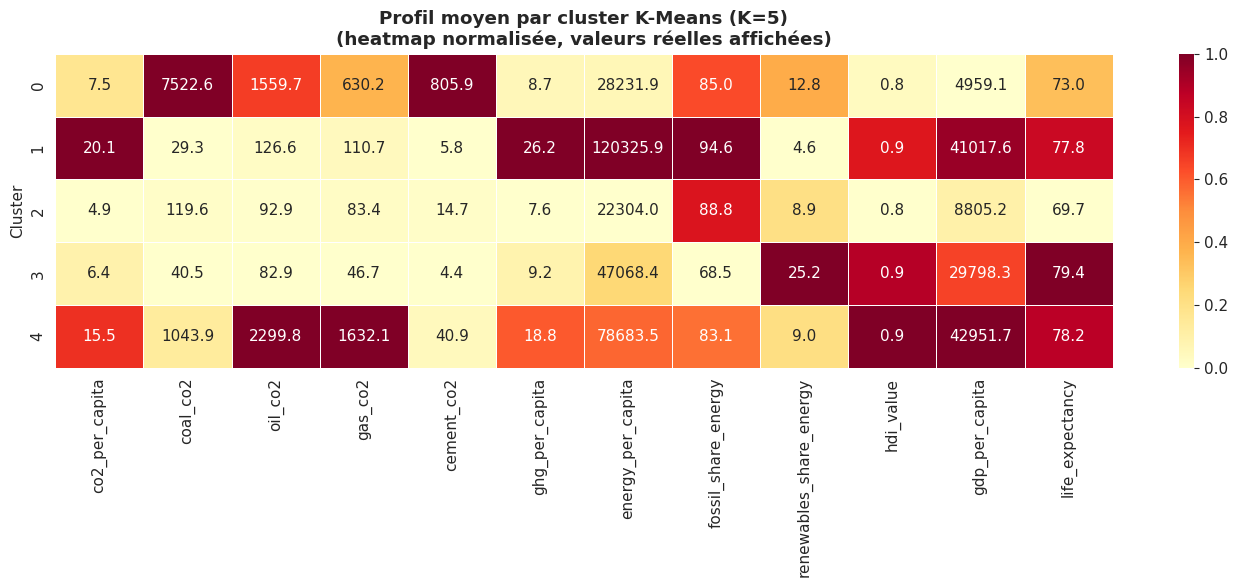

Exemples de pays par cluster :
  Cluster 0 : China
  Cluster 1 : Australia, Canada, Kuwait, Oman, Qatar, Saudi Arabia, Singapore, United Arab Emirates
  Cluster 2 : Algeria, Argentina, Azerbaijan, Bangladesh, Belarus, Bulgaria, Colombia, Egypt
  Cluster 3 : Austria, Belgium, Brazil, Chile, Croatia, Cyprus, Denmark, Finland
  Cluster 4 : United States


In [23]:
# ============================================================
# 4.7 PROFIL MOYEN PAR CLUSTER (K-MEANS)
# ============================================================

df_clust = df_analysis[mask_hdi].copy()
df_clust['cluster_km'] = labels_km_opt

cluster_profile = df_clust.groupby('cluster_km')[feature_cols].mean()

fig, ax = plt.subplots(figsize=(14, 6))
profile_norm = (cluster_profile - cluster_profile.min()) / (cluster_profile.max() - cluster_profile.min())
sns.heatmap(profile_norm, annot=cluster_profile.round(1).values, fmt='',
            cmap='YlOrRd', ax=ax, linewidths=0.5)
ax.set_title(f'Profil moyen par cluster K-Means (K={k_best_sil})\n(heatmap normalisée, valeurs réelles affichées)',
             fontweight='bold')
ax.set_ylabel('Cluster')
plt.tight_layout()
plt.show()

# Exemples de pays par cluster
print("Exemples de pays par cluster :")
for c in sorted(df_clust['cluster_km'].unique()):
    pays = df_clust[df_clust['cluster_km'] == c]['country'].values[:8]
    print(f"  Cluster {c} : {', '.join(pays)}")

---
## 5. Indice de "Justice Climatique"

### Définition de l'indice

On construit un indicateur mesurant le **décalage entre la contribution aux émissions et la vulnérabilité/développement** d'un pays.

**Idée** : un pays "injuste climatiquement" est un pays qui émet beaucoup de CO2 par habitant tout en ayant un développement humain élevé, tandis que les pays les plus vulnérables (HDI faible) émettent très peu.

$$\text{Justice Index} = \frac{\text{CO2 per capita (normalisé)}}{\text{HDI (normalisé)}}$$

- **Valeur élevée** : forte responsabilité climatique relative au développement (ex: pays pétroliers du Golfe)
- **Valeur faible** : faible responsabilité malgré un développement correct

On propose aussi un indice alternatif basé sur le rang :
$$\text{Gap Index} = \text{Rang(CO2/hab)} - \text{Rang(HDI)}$$

Un Gap positif élevé signifie que le pays pollue beaucoup plus que ce que son niveau de développement "justifierait".

In [24]:
# ============================================================
# 5.1 CONSTRUCTION DE L'INDICE DE JUSTICE CLIMATIQUE
# ============================================================

df_justice = df_analysis[mask_hdi].copy()

# --- Indice 1 : ratio normalisé CO2/HDI ---
scaler_mm = MinMaxScaler()
df_justice['co2_norm'] = scaler_mm.fit_transform(df_justice[['co2_per_capita']])
df_justice['hdi_norm'] = scaler_mm.fit_transform(df_justice[['hdi_value']])
# Éviter division par zéro
df_justice['hdi_norm'] = df_justice['hdi_norm'].clip(lower=0.01)
df_justice['justice_index'] = df_justice['co2_norm'] / df_justice['hdi_norm']

# --- Indice 2 : gap de rang ---
df_justice['rank_co2'] = df_justice['co2_per_capita'].rank(pct=True)
df_justice['rank_hdi'] = df_justice['hdi_value'].rank(pct=True)
df_justice['gap_index'] = df_justice['rank_co2'] - df_justice['rank_hdi']

# Top 10 pays les plus "injustes" (polluent beaucoup par rapport à leur HDI)
print("Top 10 pays avec le plus fort décalage émissions/développement :")
print("=" * 60)
top_unjust = df_justice.nlargest(10, 'justice_index')[
    ['country', 'co2_per_capita', 'hdi_value', 'justice_index', 'gap_index']
]
print(top_unjust.to_string(index=False))

print("\nTop 10 pays les plus 'vertueux' (faible CO2 pour leur HDI) :")
print("=" * 60)
top_just = df_justice.nsmallest(10, 'justice_index')[
    ['country', 'co2_per_capita', 'hdi_value', 'justice_index', 'gap_index']
]
print(top_just.to_string(index=False))

Top 10 pays avec le plus fort décalage émissions/développement :
             country  co2_per_capita  hdi_value  justice_index  gap_index
               Qatar          36.252      0.869       1.277108   0.434783
              Kuwait          23.559      0.838       0.907479   0.565217
        Saudi Arabia          23.245      0.862       0.828983   0.449275
            Pakistan           0.827      0.537       0.706337   0.014493
          Kazakhstan          15.411      0.810       0.645850   0.528986
United Arab Emirates          21.760      0.933       0.635786   0.159420
                Oman          15.690      0.841       0.590897   0.478261
        Turkmenistan           9.150      0.732       0.522609   0.652174
           Australia          16.283      0.941       0.462080   0.065217
       United States          15.500      0.933       0.447916   0.115942

Top 10 pays les plus 'vertueux' (faible CO2 pour leur HDI) :
    country  co2_per_capita  hdi_value  justice_index  gap_

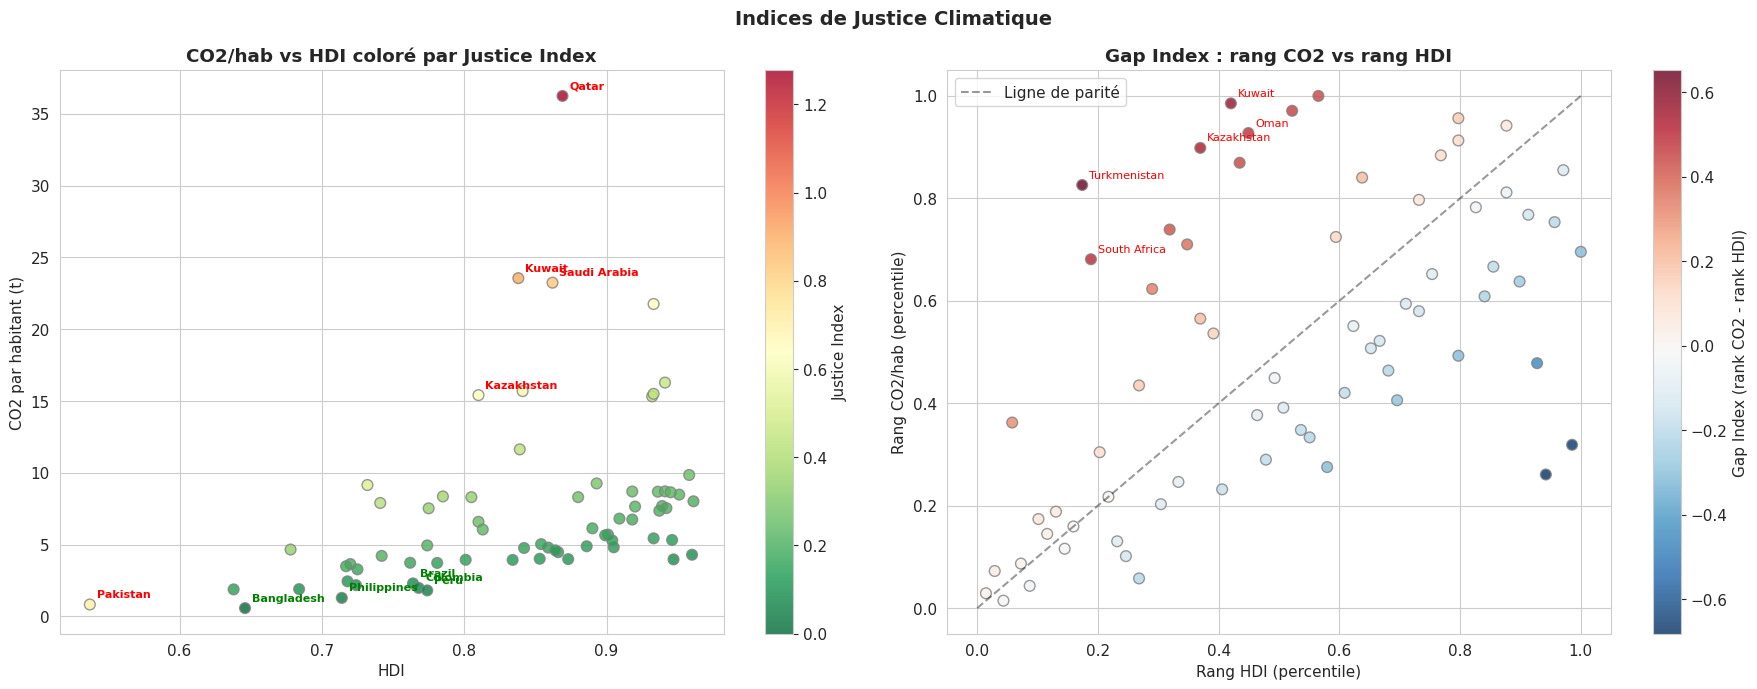

In [25]:
# ============================================================
# 5.2 VISUALISATION DE L'INDICE – SCATTER PLOT
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# --- Scatter CO2/hab vs HDI coloré par justice_index ---
sc = axes[0].scatter(df_justice['hdi_value'], df_justice['co2_per_capita'],
                     c=df_justice['justice_index'], cmap='RdYlGn_r',
                     s=60, alpha=0.8, edgecolors='gray')
plt.colorbar(sc, ax=axes[0], label='Justice Index')
axes[0].set_xlabel('HDI')
axes[0].set_ylabel('CO2 par habitant (t)')
axes[0].set_title('CO2/hab vs HDI coloré par Justice Index', fontweight='bold')

# Annoter les extrêmes
for _, row in df_justice.nlargest(5, 'justice_index').iterrows():
    axes[0].annotate(row['country'], (row['hdi_value'], row['co2_per_capita']),
                     fontsize=8, fontweight='bold', color='red',
                     textcoords="offset points", xytext=(5,5))
for _, row in df_justice.nsmallest(5, 'justice_index').iterrows():
    axes[0].annotate(row['country'], (row['hdi_value'], row['co2_per_capita']),
                     fontsize=8, fontweight='bold', color='green',
                     textcoords="offset points", xytext=(5,5))

# --- Gap Index ---
sc = axes[1].scatter(df_justice['rank_hdi'], df_justice['rank_co2'],
                     c=df_justice['gap_index'], cmap='RdBu_r',
                     s=60, alpha=0.8, edgecolors='gray')
plt.colorbar(sc, ax=axes[1], label='Gap Index (rank CO2 - rank HDI)')
axes[1].plot([0,1],[0,1], 'k--', alpha=0.4, label='Ligne de parité')
axes[1].set_xlabel('Rang HDI (percentile)')
axes[1].set_ylabel('Rang CO2/hab (percentile)')
axes[1].set_title('Gap Index : rang CO2 vs rang HDI', fontweight='bold')
axes[1].legend()

for _, row in df_justice.nlargest(5, 'gap_index').iterrows():
    axes[1].annotate(row['country'], (row['rank_hdi'], row['rank_co2']),
                     fontsize=8, color='red', textcoords="offset points", xytext=(5,5))

plt.suptitle("Indices de Justice Climatique", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

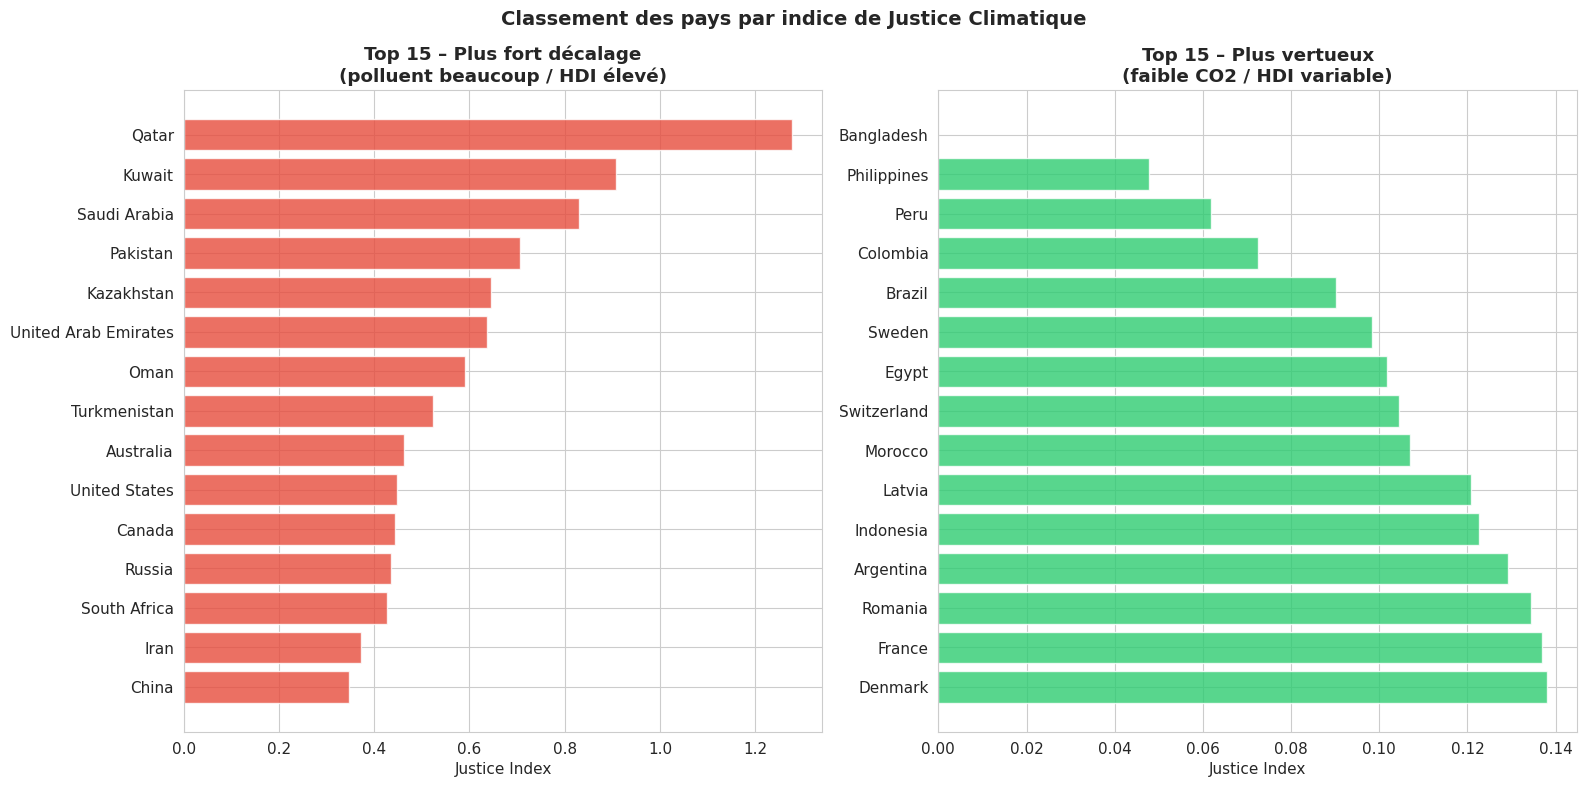

In [26]:
# ============================================================
# 5.3 CLASSEMENT PAR JUSTICE INDEX (barplot horizontal)
# ============================================================

# Top 15 et Bottom 15
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

top15 = df_justice.nlargest(15, 'justice_index').sort_values('justice_index')
axes[0].barh(top15['country'], top15['justice_index'], color='#e74c3c', alpha=0.8)
axes[0].set_xlabel('Justice Index')
axes[0].set_title('Top 15 – Plus fort décalage\n(polluent beaucoup / HDI élevé)', fontweight='bold')

bot15 = df_justice.nsmallest(15, 'justice_index').sort_values('justice_index', ascending=False)
axes[1].barh(bot15['country'], bot15['justice_index'], color='#2ecc71', alpha=0.8)
axes[1].set_xlabel('Justice Index')
axes[1].set_title('Top 15 – Plus vertueux\n(faible CO2 / HDI variable)', fontweight='bold')

plt.suptitle('Classement des pays par indice de Justice Climatique', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [27]:
# ============================================================
# 5.4 CARTE MONDIALE DE L'INDICE (Plotly choropleth)
# ============================================================

fig = px.choropleth(
    df_justice,
    locations='iso_code',
    color='justice_index',
    hover_name='country',
    hover_data={'co2_per_capita': ':.1f', 'hdi_value': ':.3f', 'justice_index': ':.2f'},
    color_continuous_scale='RdYlGn_r',
    title='Carte mondiale – Indice de Justice Climatique (2019)',
    labels={'justice_index': 'Justice Index'}
)
fig.update_layout(
    geo=dict(showframe=False, showcoastlines=True),
    width=900, height=500,
    margin=dict(l=0, r=0, t=40, b=0)
)
fig.show()

---
## 6. Visualisation t-SNE

Projection non linéaire en 2D avec t-SNE, colorée successivement par :
1. **Région géographique** (continent)
2. **Cluster** (K-Means)
3. **Justice Index**

Cela permet de vérifier si la structure non-linéaire des données révèle des groupements cohérents avec la géographie ou le clustering.

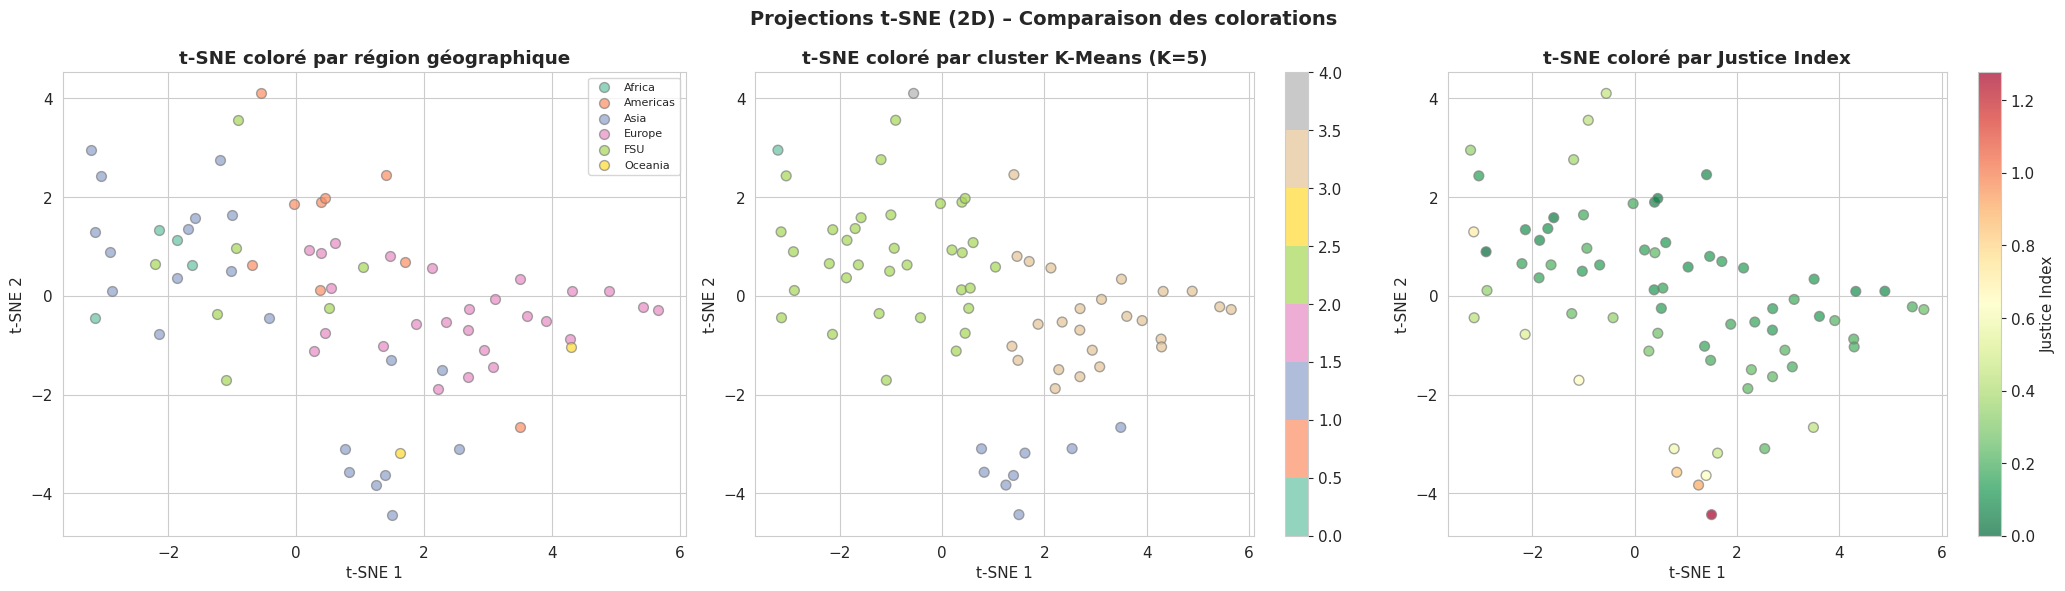

In [28]:
# ============================================================
# 6.1 t-SNE – PROJECTION 2D
# ============================================================

# t-SNE sur les données standardisées (pays avec HDI)
tsne = TSNE(n_components=2, perplexity=30, random_state=42, n_iter=1000, learning_rate='auto')
X_tsne = tsne.fit_transform(X_clust)

df_tsne = df_justice.copy()
df_tsne['tSNE_1'] = X_tsne[:, 0]
df_tsne['tSNE_2'] = X_tsne[:, 1]
df_tsne['cluster_km'] = labels_km_opt

# --- 3 visualisations côte à côte ---
fig, axes = plt.subplots(1, 3, figsize=(21, 6))

# 1) Par continent
if 'continent' in df_tsne.columns:
    continents = df_tsne['continent'].dropna().unique()
    palette = sns.color_palette('Set2', len(continents))
    for cont, color in zip(sorted(continents), palette):
        m = df_tsne['continent'] == cont
        axes[0].scatter(X_tsne[m.values, 0], X_tsne[m.values, 1], c=[color],
                        label=cont, alpha=0.7, s=50, edgecolors='gray')
    axes[0].legend(fontsize=8, loc='best')
else:
    # Fallback : colorer par hdicode
    for code, color in colors_hdi.items():
        m = y_true == code
        axes[0].scatter(X_tsne[m, 0], X_tsne[m, 1], c=color,
                        label=['Low','Medium','High','Very High'][code], alpha=0.7, s=50)
    axes[0].legend(fontsize=8)
axes[0].set_title('t-SNE coloré par région géographique', fontweight='bold')

# 2) Par cluster K-Means
sc = axes[1].scatter(X_tsne[:, 0], X_tsne[:, 1], c=labels_km_opt,
                     cmap='Set2', alpha=0.7, s=50, edgecolors='gray')
axes[1].set_title(f't-SNE coloré par cluster K-Means (K={k_best_sil})', fontweight='bold')
plt.colorbar(sc, ax=axes[1])

# 3) Par Justice Index
sc = axes[2].scatter(X_tsne[:, 0], X_tsne[:, 1], c=df_tsne['justice_index'].values,
                     cmap='RdYlGn_r', alpha=0.7, s=50, edgecolors='gray')
axes[2].set_title('t-SNE coloré par Justice Index', fontweight='bold')
plt.colorbar(sc, ax=axes[2], label='Justice Index')

for ax in axes:
    ax.set_xlabel('t-SNE 1')
    ax.set_ylabel('t-SNE 2')

plt.suptitle('Projections t-SNE (2D) – Comparaison des colorations', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [29]:
# ============================================================
# 6.2 t-SNE INTERACTIF (Plotly)
# ============================================================

fig = px.scatter(
    df_tsne, x='tSNE_1', y='tSNE_2',
    color='justice_index',
    color_continuous_scale='RdYlGn_r',
    hover_name='country',
    hover_data={'co2_per_capita': ':.1f', 'hdi_value': ':.3f',
                'justice_index': ':.2f', 'tSNE_1': False, 'tSNE_2': False},
    title='t-SNE interactif – coloré par Justice Index',
    labels={'justice_index': 'Justice Index'}
)
fig.update_traces(marker=dict(size=8, line=dict(width=0.5, color='gray')))
fig.update_layout(width=800, height=600)
fig.show()

---
## 7. Analyse critique

### Ce qui fonctionne bien
- **L'ACP** capture efficacement l'axe principal "développement/richesse vs pauvreté" qui est le driver majeur de la variabilité entre pays.
- **La NMF** sur les données énergétiques produit des profils interprétables car la contrainte de positivité correspond à la nature physique des données (on ne peut pas consommer une quantité négative d'énergie).
- **L'ICA** sépare les sources de CO2 de manière plus fine que l'ACP, identifiant des facteurs indépendants (dépendance charbon vs gaz vs pétrole).
- Le **Justice Index** met en évidence le paradoxe climatique : les pays du Golfe et certains pays industrialisés ont un décalage fort entre leurs émissions et leur vulnérabilité.

### Limites et difficultés
- **Fusion multi-sources** : les noms de pays ne sont pas toujours cohérents entre bases (ex: "Côte d'Ivoire" vs "Cote d'Ivoire"), ce qui entraîne des pertes lors des jointures.
- **Gapminder** s'arrête souvent avant 2019, forçant à utiliser des données plus anciennes pour le PIB/hab.
- **DBSCAN** est sensible au choix d'epsilon et produit souvent un grand cluster + du bruit, ce qui est moins informatif que K-Means pour ce type de données.
- L'indice de justice climatique est simpliste : il ne prend pas en compte les **émissions historiques cumulées**, le **transfert d'émissions** via le commerce, ni la **vulnérabilité climatique réelle** (exposition aux catastrophes, capacité d'adaptation).

### Améliorations possibles
- Intégrer les **émissions cumulées** depuis 1900 pour une mesure plus équitable de la responsabilité historique.
- Utiliser un **indice de vulnérabilité climatique** (ex: ND-GAIN) plutôt que le HDI seul.
- Appliquer un **clustering hiérarchique** (dendrogramme) pour visualiser les proximités entre pays à différentes échelles.
- Analyser l'**évolution temporelle** (trajectoires des pays dans l'espace ACP au fil des années).

In [30]:
# ============================================================
# 7.1 RÉSUMÉ DES RÉSULTATS
# ============================================================

print("=" * 65)
print("       RÉSUMÉ DES RÉSULTATS – PROJET JUSTICE CLIMATIQUE")
print("=" * 65)

print("\n1. DONNÉES")
print(f"   - {df_analysis.shape[0]} pays analysés, {len(feature_cols)} features")
print(f"   - 4 sources fusionnées : CO2, Energy, HDI, Gapminder")
print(f"   - Année de référence : 2019")

print("\n2. RÉDUCTION DE DIMENSION")
print(f"   - ACP : {n_comp_80} composantes pour 80% de variance")
print(f"   - NMF : {N_COMP_NMF} profils énergétiques archétypaux extraits")
print(f"   - ICA : {n_ica} composantes indépendantes, non-gaussianité confirmée")

print("\n3. CLUSTERING")
print(f"   - K optimal (silhouette) : {k_best_sil}")
print(f"   - K optimal GMM (BIC) : {k_best_bic}")
print(f"   - ARI K-Means(K=4) vs HDI : {ari_km4:.3f}")

print("\n4. JUSTICE CLIMATIQUE")
top3 = df_justice.nlargest(3, 'justice_index')['country'].values
bot3 = df_justice.nsmallest(3, 'justice_index')['country'].values
print(f"   - Pays au plus fort décalage : {', '.join(top3)}")
print(f"   - Pays les plus vertueux : {', '.join(bot3)}")
print("\n" + "=" * 65)

       RÉSUMÉ DES RÉSULTATS – PROJET JUSTICE CLIMATIQUE

1. DONNÉES
   - 69 pays analysés, 12 features
   - 4 sources fusionnées : CO2, Energy, HDI, Gapminder
   - Année de référence : 2019

2. RÉDUCTION DE DIMENSION
   - ACP : 4 composantes pour 80% de variance
   - NMF : 4 profils énergétiques archétypaux extraits
   - ICA : 4 composantes indépendantes, non-gaussianité confirmée

3. CLUSTERING
   - K optimal (silhouette) : 5
   - K optimal GMM (BIC) : 9
   - ARI K-Means(K=4) vs HDI : 0.083

4. JUSTICE CLIMATIQUE
   - Pays au plus fort décalage : Qatar, Kuwait, Saudi Arabia
   - Pays les plus vertueux : Bangladesh, Philippines, Peru

